# Computational Linear Algebra: PCA Homework

## Exercise 0.0: Initialization
Fill the missing values in this text box. **Remove the information of the second student if you are not working in a team**.

**Academic Year:** 2025/2026

### Team Members (Alphabetical Order):
1. Miori, Arianna (s353777);

Now, fill the python list below with the Student IDs of the team

In [1]:
StudentIDs = [353777]  # <-------- Fill this list with Student IDs of the team

## Exercise 0.1: Starting Code-Cell 

Download the .csv files from the web page of the course (*responses_hw.csv* and *columns_hw.csv*) and past them in **the same folder of this notebook**.


Then, run the cell below, **without modifing any line of code**.

The output of this code cell is **your personal subset of the original dataset**, with 2/3 of the original features (i.e., columns) and 3/4 of the original persons (i.e., rows).

### ATTENTION: DO NOT CHANGE THE CODE INSIDE THE FOLLOWING CELL, ANY CHANGE CAN INVALIDATE THE HOMEWORK!

In [2]:
####################################################################
############## DO NOT CHANGE THE CODE IN THIS CELL #################
####################################################################

import numpy as np
import pandas as pd
from IPython.display import display

var_entertainment_feat_types = ['Interests', 'Movies', 'Music']
var_personal_feat_types = ['Finance', 'Phobias']
fixed_feat_types = ['Personality', 'Health']

label_types = ['Demographic']

variables_by_type = {
    'Demographics': ['Age', 'Height', 'Weight', 'Number of siblings', 
                     'Gender', 'Hand', 'Education', 'Only child', 'Home Town Type',
                     'Home Type'],
    'Finance': ['Finances', 'Shopping centres', 'Branded clothing', 
                'Entertainment spending', 'Spending on looks', 
                'Spending on gadgets', 'Spending on healthy eating'],
    'Health': ['Smoking', 'Alcohol', 'Healthy eating'],
    'Interests': ['History', 'Psychology', 'Politics', 'Mathematics', 
                  'Physics', 'Internet', 'PC', 'Economy Management', 
                  'Biology', 'Chemistry', 'Reading', 'Geography', 
                  'Foreign languages', 'Medicine', 'Law', 'Cars', 
                  'Art exhibitions', 'Religion', 'Countryside, outdoors', 
                  'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 
                  'Active sport', 'Gardening', 'Celebrities', 'Shopping', 
                  'Science and technology', 'Theatre', 'Fun with friends', 
                  'Adrenaline sports', 'Pets'],
    'Movies': ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 
               'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 
               'Documentary', 'Western', 'Action'],
    'Music': ['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 
              'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 
              'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 
              'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 
              'Techno, Trance', 'Opera'],
    'Personality': ['Daily events', 'Prioritising workload', 
                    'Writing notes', 'Workaholism', 'Thinking ahead', 
                    'Final judgement', 'Reliability', 'Keeping promises', 
                    'Loss of interest', 'Friends versus money', 'Funniness', 
                    'Fake', 'Criminal damage', 'Decision making', 'Elections', 
                    'Self-criticism', 'Judgment calls', 'Hypochondria', 
                    'Empathy', 'Eating to survive', 'Giving', 
                    'Compassion to animals', 'Borrowed stuff', 
                    'Loneliness', 'Cheating in school', 'Health', 
                    'Changing the past', 'God', 'Dreams', 'Charity', 
                    'Number of friends', 'Punctuality', 'Lying', 'Waiting', 
                    'New environment', 'Mood swings', 'Appearence and gestures', 
                    'Socializing', 'Achievements', 'Responding to a serious letter', 
                    'Children', 'Assertiveness', 'Getting angry', 
                    'Knowing the right people', 'Public speaking', 
                    'Unpopularity', 'Life struggles', 'Happiness in life', 
                    'Energy levels', 'Small - big dogs', 'Personality', 
                    'Finding lost valuables', 'Getting up', 'Interests or hobbies', 
                    "Parents' advice", 'Questionnaires or polls', 'Internet usage'],
    'Phobias': ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 
                'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking']
}

labels = variables_by_type['Demographics']
features_all = []
for tt in variables_by_type.keys():
    if tt != 'Demographics':
        features_all += variables_by_type[tt]

def which_features(*StudentIDs):
    random_seed = min(StudentIDs)
    np.random.seed(random_seed)
    features_ = np.random.choice(features_all, int((2 * len(features_all)) / 3), replace=False).tolist()
    features = []
    features_by_type = {tt: [] for tt in variables_by_type.keys() if tt != 'Demographics'}
    for tt in variables_by_type.keys():
        ft_list = variables_by_type[tt]
        for ii in range(len(ft_list)):
            if ft_list[ii] in features_:
                features.append(ft_list[ii])
                features_by_type[tt].append(ft_list[ii])

    return features, features_by_type

features, features_by_type = which_features(*StudentIDs)

print(f'*** THESE ARE THE {len(features)} SELECTED FEATURES (SEE VARIABLE features):')
for ff in features:
    print(f'{ff}')
print('*************************************')
print('')
print('*** SELECTED FEATURES BY TYPES (SEE VARIABLE features_by_type):')
for tt in features_by_type.keys():
    print(f'{tt}: {features_by_type[tt]}')
    print('')
print('*************************************')
print('')
print('*** THESE ARE THE LABELS (SEE VARIABLE labels):')
for ll in labels:
    print(f'{ll}')
print('*************************************')

def which_rows(df, frac, *StudentIDs):
    random_seed = min(StudentIDs)
    df_ = df.sample(frac=frac, random_state=random_seed)
    return df_

responses_hw = pd.read_csv('responses_hw.csv', index_col=0)
responses = which_rows(responses_hw, 0.75, *StudentIDs)
responses = responses.loc[:, features + labels]

responses_ft = responses.loc[:, features]
responses_lb = responses.loc[:, labels]

print('')
print('*** THIS IS YOUR PERSONAL DATASET (features AND labels TOGETHER, SEE VARIABLE responses)')
display(responses)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)')
display(responses_ft)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)')
display(responses_lb)

random_seed = min(StudentIDs)
np.random.seed(random_seed)

your_scaler = np.random.choice(['StandardScaler', 'MinMaxScaler'])


*** THESE ARE THE 93 SELECTED FEATURES (SEE VARIABLE features):
Finances
Shopping centres
Entertainment spending
Spending on looks
Spending on gadgets
Spending on healthy eating
Smoking
Alcohol
Psychology
Politics
Internet
PC
Economy Management
Reading
Geography
Law
Countryside, outdoors
Dancing
Writing
Gardening
Celebrities
Shopping
Science and technology
Theatre
Adrenaline sports
Pets
Movies
Horror
Thriller
Comedy
Animated
Western
Action
Music
Dance
Folk
Classical music
Musical
Rock
Metal or Hardrock
Punk
Hiphop, Rap
Reggae, Ska
Swing, Jazz
Rock n roll
Alternative
Latino
Prioritising workload
Thinking ahead
Final judgement
Reliability
Friends versus money
Funniness
Fake
Criminal damage
Self-criticism
Judgment calls
Hypochondria
Eating to survive
Giving
Borrowed stuff
Loneliness
Cheating in school
Health
Changing the past
God
Charity
Number of friends
Waiting
New environment
Mood swings
Appearence and gestures
Achievements
Assertiveness
Getting angry
Unpopularity
Life struggles
Happin

,Finances,Shopping centres,Entertainment spending,Spending on looks,Spending on gadgets,Spending on healthy eating,Smoking,Alcohol,Psychology,Politics,...,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
316,2,4,4,5,3,3,former smoker,drink a lot,2,3,...,18,163,58,6,female,right,secondary school,no,city,block of flats
53,3,3,3,2,1,3,never smoked,never,3,3,...,24,160,58,0,female,right,college/bachelor degree,yes,village,house/bungalow
568,1,5,5,5,5,2,tried smoking,social drinker,3,4,...,19,187,88,0,male,right,secondary school,yes,city,block of flats
549,2,5,5,5,2,4,never smoked,drink a lot,3,5,...,18,176,76,0,male,right,secondary school,yes,city,block of flats
295,3,5,3,3,4,4,tried smoking,social drinker,5,3,...,18,167,56,2,male,right,college/bachelor degree,no,city,block of flats
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,3,3,3,3,2,2,tried smoking,social drinker,3,1,...,19,164,55,1,female,right,secondary school,no,village,block of flats
541,3,1,2,3,3,4,current smoker,social drinker,4,5,...,18,160,55,2,female,right,secondary school,no,city,block of flats
47,5,1,3,1,1,4,tried smoking,social drinker,5,4,...,23,175,72,1,male,right,college/bachelor degree,no,city,block of flats
204,5,1,3,3,4,3,never smoked,social drinker,1,1,...,20,178,68,2,male,right,secondary school,no,city,block of flats



*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)


,Finances,Shopping centres,Entertainment spending,Spending on looks,Spending on gadgets,Spending on healthy eating,Smoking,Alcohol,Psychology,Politics,...,Interests or hobbies,Parents' advice,Questionnaires or polls,Internet usage,Flying,Darkness,Heights,Snakes,Rats,Dangerous dogs
316,2,4,4,5,3,3,former smoker,drink a lot,2,3,...,4,3,1,few hours a day,2,2,2,4,3,3
53,3,3,3,2,1,3,never smoked,never,3,3,...,4,2,3,few hours a day,1,2,4,3,2,5
568,1,5,5,5,5,2,tried smoking,social drinker,3,4,...,5,2,1,few hours a day,1,1,3,1,1,1
549,2,5,5,5,2,4,never smoked,drink a lot,3,5,...,5,2,1,most of the day,1,1,2,5,1,4
295,3,5,3,3,4,4,tried smoking,social drinker,5,3,...,5,3,4,few hours a day,1,3,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,3,3,3,3,2,2,tried smoking,social drinker,3,1,...,5,3,3,few hours a day,3,4,3,5,4,5
541,3,1,2,3,3,4,current smoker,social drinker,4,5,...,1,3,1,few hours a day,1,1,2,1,5,3
47,5,1,3,1,1,4,tried smoking,social drinker,5,4,...,5,3,2,most of the day,1,1,2,3,2,3
204,5,1,3,3,4,3,never smoked,social drinker,1,1,...,5,3,1,most of the day,1,1,4,3,1,3



*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)


,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
316,18,163,58,6,female,right,secondary school,no,city,block of flats
53,24,160,58,0,female,right,college/bachelor degree,yes,village,house/bungalow
568,19,187,88,0,male,right,secondary school,yes,city,block of flats
549,18,176,76,0,male,right,secondary school,yes,city,block of flats
295,18,167,56,2,male,right,college/bachelor degree,no,city,block of flats
...,...,...,...,...,...,...,...,...,...,...
419,19,164,55,1,female,right,secondary school,no,village,block of flats
541,18,160,55,2,female,right,secondary school,no,city,block of flats
47,23,175,72,1,male,right,college/bachelor degree,no,city,block of flats
204,20,178,68,2,male,right,secondary school,no,city,block of flats


## Exercise 0.2: Importing Modules

In the following cell, import all the modules you think are necessary for doing the homework, **among the ones listed and used during the laboratories of the course**.

For reproducibility, **no extra modules are allowed**.

**DO NOT IMPORT NUMPY NOR PANDAS**, they are already imported.

In [3]:
# DO NOT IMPORT NUMPY AND PANDAS - Already imported
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

## Exercise 1. Dataset Preprocessing

In this exercise, you have to do the following operations on the dataset of the features **responses_ft**:
1. Create a new dataframe called **responses_ft_enc** by encoding the categorical features (if they exist), motivating your choices;
1. Create a new dataframe called **responses_ft_pp** by preprocessing the data in **responses_ft_enc**, according to the scaler reported in the cell below.

In [4]:
print(f'*** YOU HAVE TO APPLY A PREPROCESSING USING THE {your_scaler}')

*** YOU HAVE TO APPLY A PREPROCESSING USING THE MinMaxScaler


For doing this exercise, fill the cells below following the instructions you read.

#### Describe and motivate the encoding operations you will apply (max 150 words):
The dataset contains only three categorical features that require encoding. Since the responses of these features follow an incremental order, it is appropriate to use an Ordinal Encoder. In particular, this encoder works well for the "Alcohol" and "Internet usage" categories in which there is a clear increasing order in the responses. For the "Smoking" category, the responses ("never smoked", "tried smoking", "former smoker", "current smoker") are ordinal, but they do not follow a strictly linear progression and, in general, a OneHotEncoder may be more appropriate.
However, using an Ordinal Encoder is acceptable in this context, as PCA will be applied; this approach ensures that all features maintain a consistent ordered structure, which supports both the performance and interpretability of PCA.

#### Describe the preprocessing operation you will apply and comment the effects it may have on the data (max 150 words):
The MinMaxScaler transforms features by rescaling each feature to a given range. In particular, each feature is rescaled using the minimum and the maximum values and mapped within the range [0,1]. Although in this case it is required to use the MinMaxScaler, it is appropriate here because it preserves the ordered structure of the dataset.

#### Write the code for performing the encoding and preprocessing operations of the exercise. Show the encoded data and the preprocessed data you obtain, plus any additional table/value that can be useful for commenting the results:

In [5]:
# I check which are the columns that have object as type
print(responses_ft.select_dtypes(include='object').columns)

objs = ["Smoking", "Alcohol", "Internet usage"]

# I divide the dataframe in the categorical and numerical values
obj_responses_ft = responses_ft[objs]
int_responses_ft = responses_ft.drop(columns=objs)

# Read the possible value in a specific categorical attribute
for col in objs:
    print(obj_responses_ft[col].value_counts())

categories = [["never smoked", "tried smoking", "former smoker", "current smoker"],
              ["never", "social drinker", "drink a lot"],
              ["less than an hour a day", "few hours a day", "most of the day"]]

# Encode the categorical data using OrdinalEncoder
oe = OrdinalEncoder(categories=categories)
objOE = oe.fit_transform(obj_responses_ft[objs])

obj_responses_ft_enc= pd.DataFrame(
    objOE,
    columns = objs,
    index = obj_responses_ft.index
)

# Generate the encoded dataframe by concatenate the numerical and encoded categorical values
responses_ft_enc = pd.concat([int_responses_ft, obj_responses_ft_enc], axis=1)
display(responses_ft_enc)

# Apply the MinMax scaler to the dataframe
minmax_scaler = MinMaxScaler()

responses_ft_pp = pd.DataFrame(
    minmax_scaler.fit_transform(responses_ft_enc),
    columns=responses_ft_enc.columns,
    index=responses_ft_enc.index
)

display(responses_ft_pp)


Index(['Smoking', 'Alcohol', 'Internet usage'], dtype='object')
Smoking
tried smoking     224
never smoked      114
former smoker      92
current smoker     76
Name: count, dtype: int64
Alcohol
social drinker    339
drink a lot       115
never              52
Name: count, dtype: int64
Internet usage
few hours a day            383
less than an hour a day     68
most of the day             55
Name: count, dtype: int64


,Finances,Shopping centres,Entertainment spending,Spending on looks,Spending on gadgets,Spending on healthy eating,Psychology,Politics,Internet,PC,...,Questionnaires or polls,Flying,Darkness,Heights,Snakes,Rats,Dangerous dogs,Smoking,Alcohol,Internet usage
316,2,4,4,5,3,3,2,3,3,4,...,1,2,2,2,4,3,3,2.0,2.0,1.0
53,3,3,3,2,1,3,3,3,3,1,...,3,1,2,4,3,2,5,0.0,0.0,1.0
568,1,5,5,5,5,2,3,4,4,4,...,1,1,1,3,1,1,1,1.0,1.0,1.0
549,2,5,5,5,2,4,3,5,4,5,...,1,1,1,2,5,1,4,0.0,2.0,2.0
295,3,5,3,3,4,4,5,3,5,4,...,4,1,3,4,4,4,4,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,3,3,3,3,2,2,3,1,4,1,...,3,3,4,3,5,4,5,1.0,1.0,1.0
541,3,1,2,3,3,4,4,5,5,2,...,1,1,1,2,1,5,3,3.0,1.0,1.0
47,5,1,3,1,1,4,5,4,5,4,...,2,1,1,2,3,2,3,1.0,1.0,2.0
204,5,1,3,3,4,3,1,1,5,4,...,1,1,1,4,3,1,3,0.0,1.0,2.0


,Finances,Shopping centres,Entertainment spending,Spending on looks,Spending on gadgets,Spending on healthy eating,Psychology,Politics,Internet,PC,...,Questionnaires or polls,Flying,Darkness,Heights,Snakes,Rats,Dangerous dogs,Smoking,Alcohol,Internet usage
316,0.25,0.75,0.75,1.00,0.50,0.50,0.25,0.50,0.50,0.75,...,0.00,0.25,0.25,0.25,0.75,0.50,0.50,0.666667,1.0,0.5
53,0.50,0.50,0.50,0.25,0.00,0.50,0.50,0.50,0.50,0.00,...,0.50,0.00,0.25,0.75,0.50,0.25,1.00,0.000000,0.0,0.5
568,0.00,1.00,1.00,1.00,1.00,0.25,0.50,0.75,0.75,0.75,...,0.00,0.00,0.00,0.50,0.00,0.00,0.00,0.333333,0.5,0.5
549,0.25,1.00,1.00,1.00,0.25,0.75,0.50,1.00,0.75,1.00,...,0.00,0.00,0.00,0.25,1.00,0.00,0.75,0.000000,1.0,1.0
295,0.50,1.00,0.50,0.50,0.75,0.75,1.00,0.50,1.00,0.75,...,0.75,0.00,0.50,0.75,0.75,0.75,0.75,0.333333,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,0.50,0.50,0.50,0.50,0.25,0.25,0.50,0.00,0.75,0.00,...,0.50,0.50,0.75,0.50,1.00,0.75,1.00,0.333333,0.5,0.5
541,0.50,0.00,0.25,0.50,0.50,0.75,0.75,1.00,1.00,0.25,...,0.00,0.00,0.00,0.25,0.00,1.00,0.50,1.000000,0.5,0.5
47,1.00,0.00,0.50,0.00,0.00,0.75,1.00,0.75,1.00,0.75,...,0.25,0.00,0.00,0.25,0.50,0.25,0.50,0.333333,0.5,1.0
204,1.00,0.00,0.50,0.50,0.75,0.50,0.00,0.00,1.00,0.75,...,0.00,0.00,0.00,0.75,0.50,0.00,0.50,0.000000,0.5,1.0


#### Comment the results obtained after the preprocessing operation (max 100 words):
As expected, the categorical features have become numerical and after the preprocessing all the values are between 0 and 1. The relative ordering of the features has been preserved, ensuring that the dataset maintains its structure.
They can now be used for variance analysis and for PCA.

## Exercise 2. Analyzing the Variance and the PCs

In this exercise, you have to do the following operations:
1. compute and visualize the variance of all the features in *responses_ft_enc* and *responses_ft_pp*;
1. compute all the $n$ Principal Components (PCs) for *responses_ft_enc* and *responses_ft_pp*, separately, and visualize the curves of the cumulative explained variances.

For doing this exercise, fill the cells below following the instructions you read.

#### Write the code for computing and visualizing the variance of the features of the two datasets:

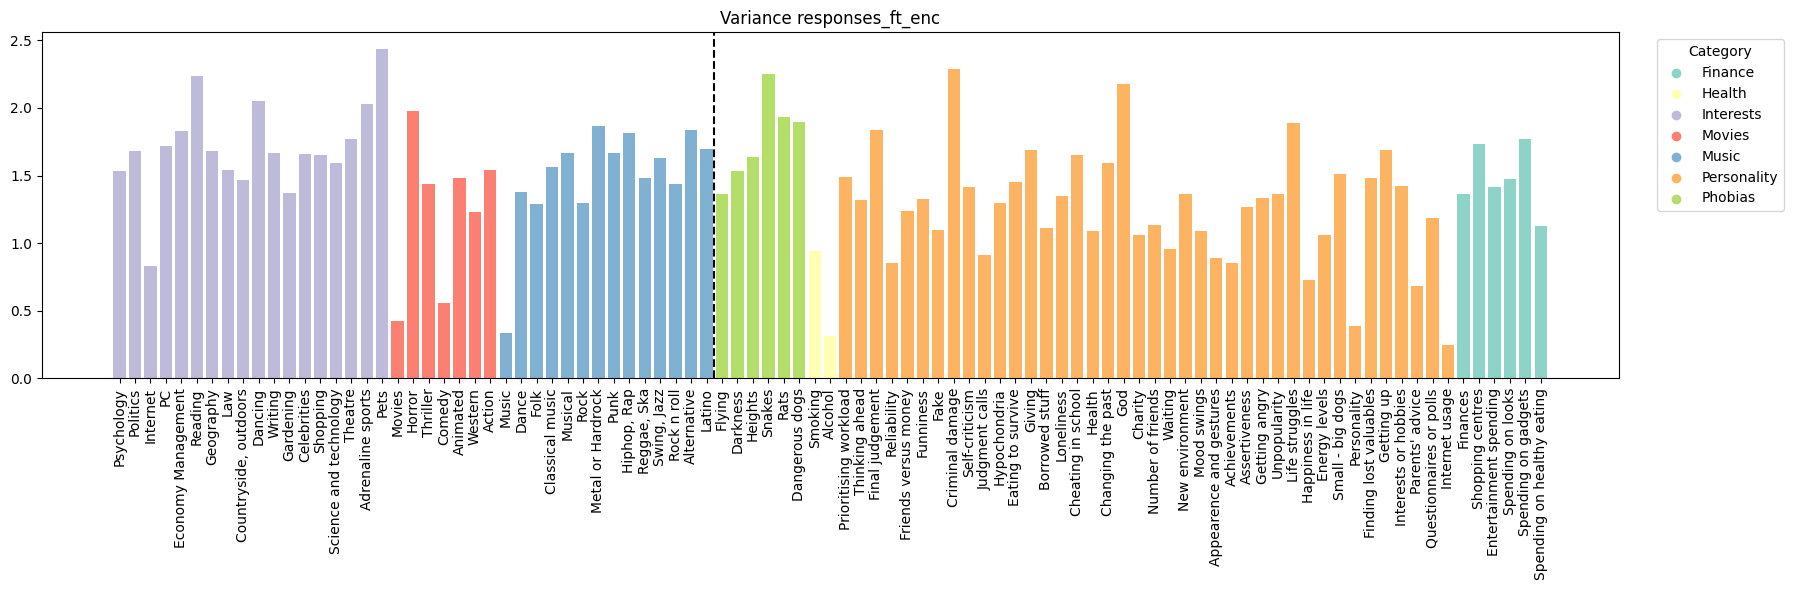

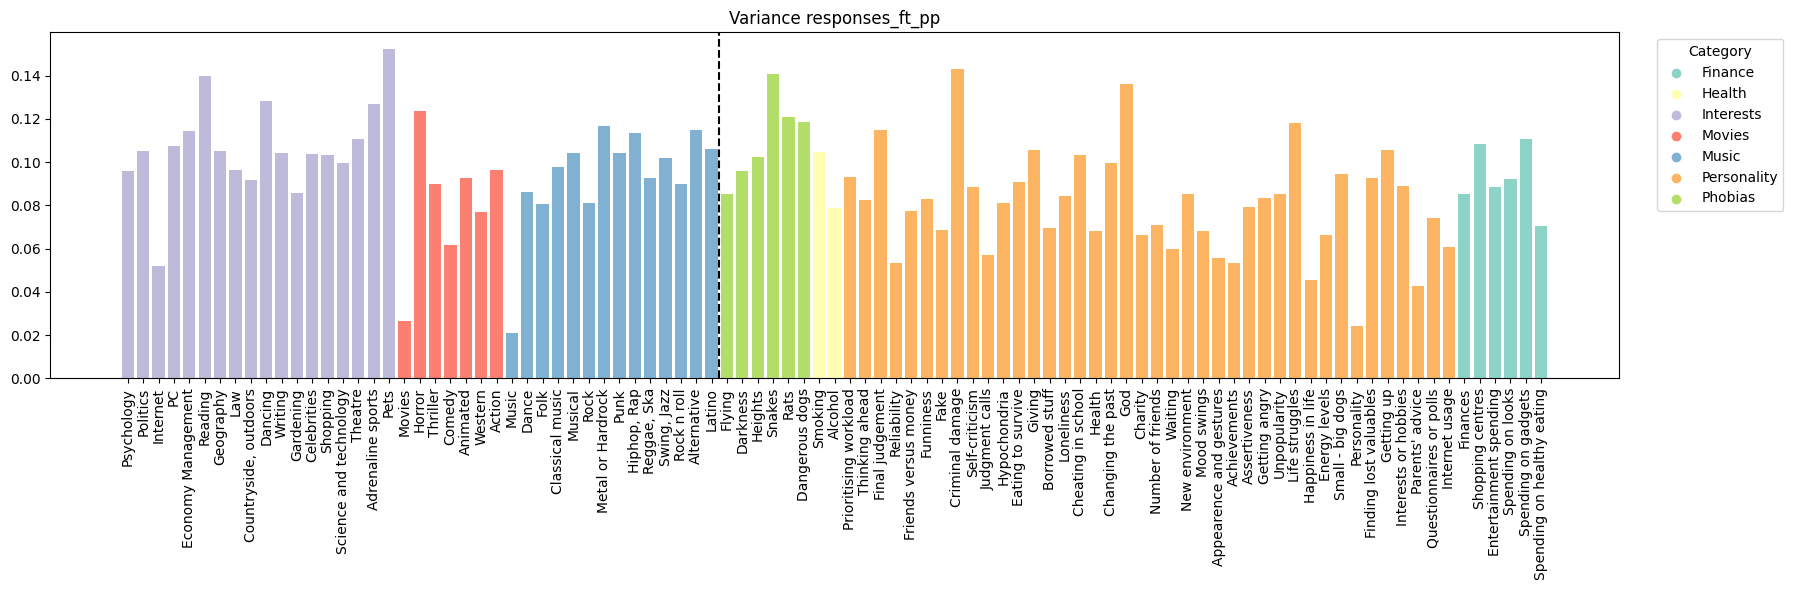

In [6]:
# For adding color to each category
Finance = ['Finances', 'Shopping centres', 'Entertainment spending', 'Spending on looks', 'Spending on gadgets', 'Spending on healthy eating']
Health = ['Smoking', 'Alcohol']
Interests = ['Psychology', 'Politics', 'Internet', 'PC', 'Economy Management', 'Reading', 'Geography', 'Law', 'Countryside, outdoors', 'Dancing', 'Writing', 'Gardening', 'Celebrities', 'Shopping', 'Science and technology', 'Theatre', 'Adrenaline sports', 'Pets']
Movies = ['Movies', 'Horror', 'Thriller', 'Comedy', 'Animated', 'Western', 'Action']
Music = ['Music', 'Dance', 'Folk', 'Classical music', 'Musical', 'Rock', 'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino']
Personality = ['Prioritising workload', 'Thinking ahead', 'Final judgement', 'Reliability', 'Friends versus money', 'Funniness', 'Fake', 'Criminal damage', 'Self-criticism', 'Judgment calls', 'Hypochondria', 'Eating to survive', 'Giving', 'Borrowed stuff', 'Loneliness', 'Cheating in school', 'Health', 'Changing the past', 'God', 'Charity', 'Number of friends', 'Waiting', 'New environment', 'Mood swings', 'Appearence and gestures', 'Achievements', 'Assertiveness', 'Getting angry', 'Unpopularity', 'Life struggles', 'Happiness in life', 'Energy levels', 'Small - big dogs', 'Personality', 'Finding lost valuables', 'Getting up', 'Interests or hobbies', "Parents' advice", 'Questionnaires or polls', 'Internet usage']
Phobias = ['Flying', 'Darkness', 'Heights', 'Snakes', 'Rats', 'Dangerous dogs']

categories = {
    'Finance': Finance,
    'Health': Health,
    'Interests': Interests,
    'Movies': Movies,
    'Music': Music,
    'Personality': Personality,
    'Phobias': Phobias
}

cmap = plt.get_cmap('Set3')

category_colors = {
    'Finance': cmap(0),
    'Health': cmap(1),
    'Interests': cmap(2),
    'Movies': cmap(3),
    'Music': cmap(4),
    'Personality': cmap(5),
    'Phobias': cmap(6)
}

column_color = {}
for cat, cols in categories.items():
    for col in cols:
        column_color[col] = category_colors[cat]

# For dividing the two groups of categories
entertainment = ['Interests', 'Movies', 'Music']
personality = ['Phobias', 'Health', 'Personality', 'Finance']

ordered_groups = entertainment + personality
ordered_columns = []
for group in ordered_groups:
    ordered_columns.extend(categories[group])

responses_ft_enc = responses_ft_enc[ordered_columns]
responses_ft_pp = responses_ft_pp[ordered_columns]

# compute the variance
var_responses_ft_enc = responses_ft_enc.var(axis=0)
var_responses_ft_pp = responses_ft_pp.var(axis=0)

# for the color in the graph
colors_enc = [column_color.get(col, 'gray') for col in var_responses_ft_enc.index]
colors_pp  = [column_color.get(col, 'gray') for col in var_responses_ft_pp.index]

# for adding a vline in the plot to separate the two groups
entertainment_cols = []
for g in ['Interests','Movies','Music']:
    entertainment_cols.extend(categories[g])
vline_pos = len(entertainment_cols) - 0.5

# plotting the variance of the encoded dataset
plt.figure(figsize=(18, 6))
plt.bar(np.arange(len(var_responses_ft_enc)), var_responses_ft_enc, color = colors_enc)
plt.axvline(x=vline_pos, color='black', linestyle='--', linewidth=1.5)
for cat, color in category_colors.items():
    plt.scatter([], [], color=color, label=cat)
plt.legend(title='Category', bbox_to_anchor=(1.02,1), loc='upper left')
plt.xticks(np.arange(len(var_responses_ft_enc)),
           var_responses_ft_enc.index,
           rotation=90,
           fontsize=10)
plt.title("Variance responses_ft_enc")
plt.tight_layout()
plt.show()

# plotting the variance of the preprocessed dataset
plt.figure(figsize=(18, 6))
plt.bar(np.arange(len(var_responses_ft_pp)), var_responses_ft_pp, color = colors_pp)
plt.axvline(x=vline_pos, color='black', linestyle='--', linewidth=1.5)
for cat, color in category_colors.items():
    plt.scatter([], [], color=color, label=cat)
plt.legend(title='Category', bbox_to_anchor=(1.02,1), loc='upper left')
plt.xticks(np.arange(len(var_responses_ft_pp)),
           var_responses_ft_pp.index,
           rotation=90,
           fontsize=10)
plt.title("Variance responses_ft_pp")
plt.tight_layout()
plt.show()


#### Comment the results obtained for the variances (max 150 words):
One can observe that the range of the values after preprocessing is between 0 and 0.16, whereas before preprocessing it ranged between 0 and 2.5. This occurs because all features are now scaled within the interval [0, 1].
After preprocessing, the categorical features ("Smoking", "Alcohol", and "Internet usage") appear to be more relevant and contribute more to the PCA analysis . In contrast, the numerical features show similar behavior, as they have only been rescaled without altering their relative structure.

#### Write the code for computing all the $n$ PCs of the two datasets, separately, and for visualizing the curves of cumulative explained variances:

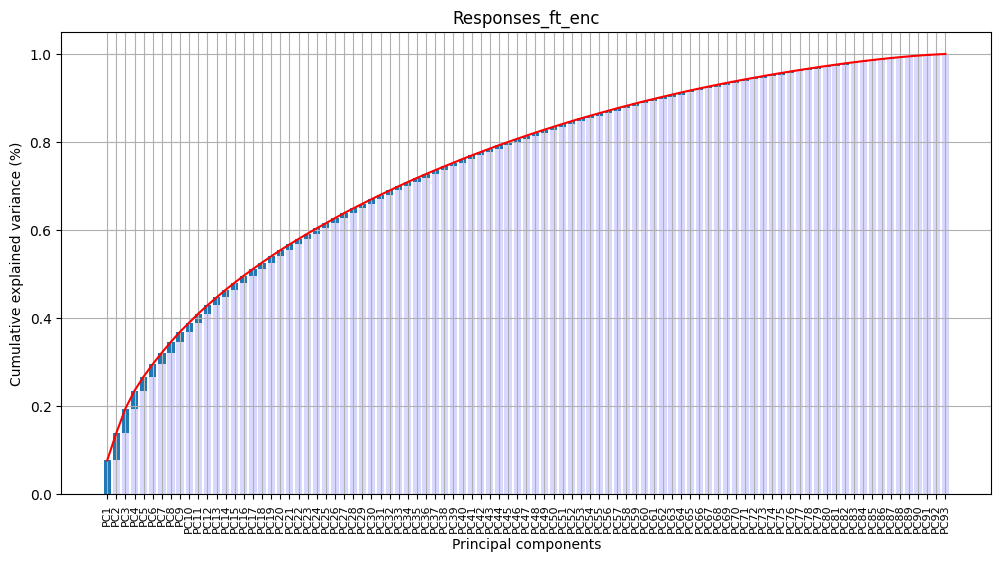

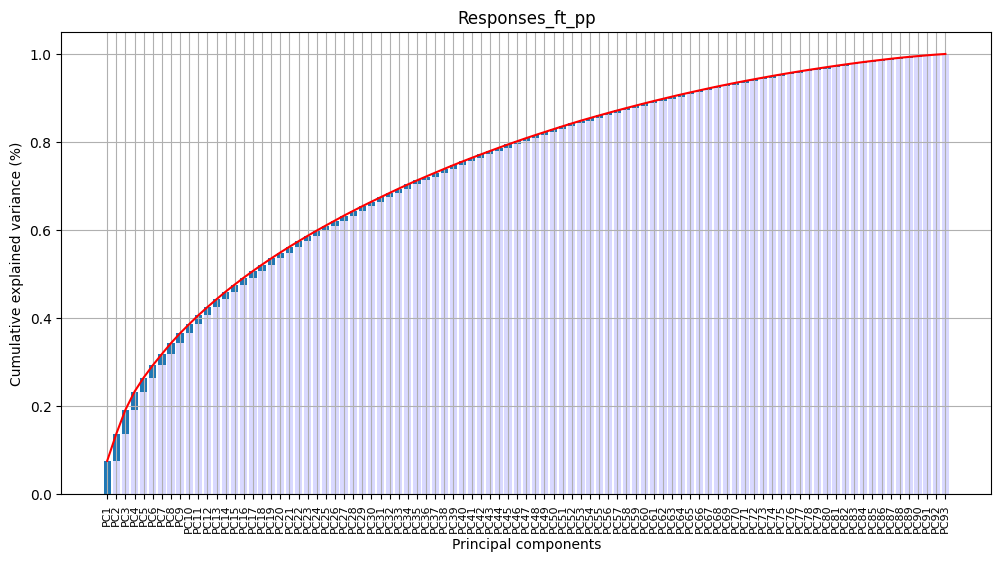

In [7]:
# PCA
pca_responses_ft_enc = PCA()
pca_responses_ft_pp = PCA()

pca_responses_ft_enc.fit(responses_ft_enc)
pca_responses_ft_pp.fit(responses_ft_pp)

# plotting the cumulative explained variance - encoded dataset
plt.figure(figsize=(12,6))
plt.bar(np.arange(pca_responses_ft_enc.n_features_in_), pca_responses_ft_enc.explained_variance_ratio_, bottom=np.insert(np.cumsum(pca_responses_ft_enc.explained_variance_ratio_), 0, 0)[:-1])
plt.bar(np.arange(pca_responses_ft_enc.n_features_in_), np.insert(np.cumsum(pca_responses_ft_enc.explained_variance_ratio_), 0, 0)[:-1], color='b', alpha=0.15)
plt.plot(np.cumsum(pca_responses_ft_enc.explained_variance_ratio_), 'r')
plt.title('Responses_ft_enc')
plt.xticks(ticks=np.arange(pca_responses_ft_enc.n_features_in_),
           labels=[f'PC{i}' for i in range(1, pca_responses_ft_enc.n_features_in_ + 1)],
           rotation = 90,
           fontsize=8)
plt.xlabel('Principal components')
plt.ylabel('Cumulative explained variance (%)')
plt.grid()
plt.show()

# plotting the cumulative explained variance - preprocessed dataset
plt.figure(figsize=(12,6))
plt.bar(np.arange(pca_responses_ft_pp.n_features_in_), pca_responses_ft_pp.explained_variance_ratio_, bottom=np.insert(np.cumsum(pca_responses_ft_pp.explained_variance_ratio_), 0, 0)[:-1])
plt.bar(np.arange(pca_responses_ft_pp.n_features_in_), np.insert(np.cumsum(pca_responses_ft_pp.explained_variance_ratio_), 0, 0)[:-1], color='b', alpha=0.15)
plt.plot(np.cumsum(pca_responses_ft_pp.explained_variance_ratio_), 'r')
# plt.hlines(y=.33, xmin=0, xmax=7, color='black', linestyle='--') this is for the next exercise
plt.title('Responses_ft_pp')
plt.xticks(ticks=np.arange(pca_responses_ft_pp.n_features_in_),
           labels=[f'PC{i}' for i in range(1, pca_responses_ft_pp.n_features_in_ + 1)],
           rotation = 90,
           fontsize=8)
plt.xlabel('Principal components')
plt.ylabel('Cumulative explained variance (%)')
plt.grid()
plt.show()

#### Comment the results obtained for the cumulative explained variances, knowing the vaues in the datasets and the fetures' variances (max 150 words):

The two cumulative explained variance curves are very similar, indicating that the inclusion of the three categorical features does not significantly affect the overall variance captured by the principal components: their contribution remains limited when compared to the total number of features in the dataset (93) and their respective variances.
In this case, the numerical features account for the majority of the variance. This suggests that the added categorical features have a marginal impact on the global variance structure captured by PCA.

## Exercise 3. Dimensionality Reduction and PC Interpretation

In this exercise, you have to do the following operations:
1. For the dataset *responses_ft_pp*, compute a new PCA for performing a dimensionality reduction with respect to $m$ dimensions. The value of $m$ must be $$m = \min\{m', 5\}\,,$$ where $m'$ is the value required for obtaining $33\%$ of the total variance.
1. Visualize all the PCs as barplots and give an interpretation and a name to them, **motivating your choices**.
1. Visualize the the score graph. If $m>3$, plot the score graph with respect to the first 3 PCs. All the **plots must show the names of the PCs (given at the previous step) on the axes** for better understanding the results.

#### Write the code for computing the new PCA, for visualizing the $m$ PCs as barplots:

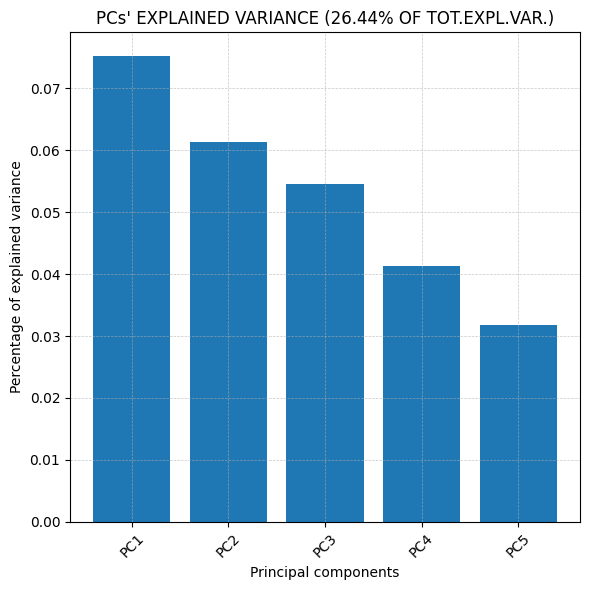

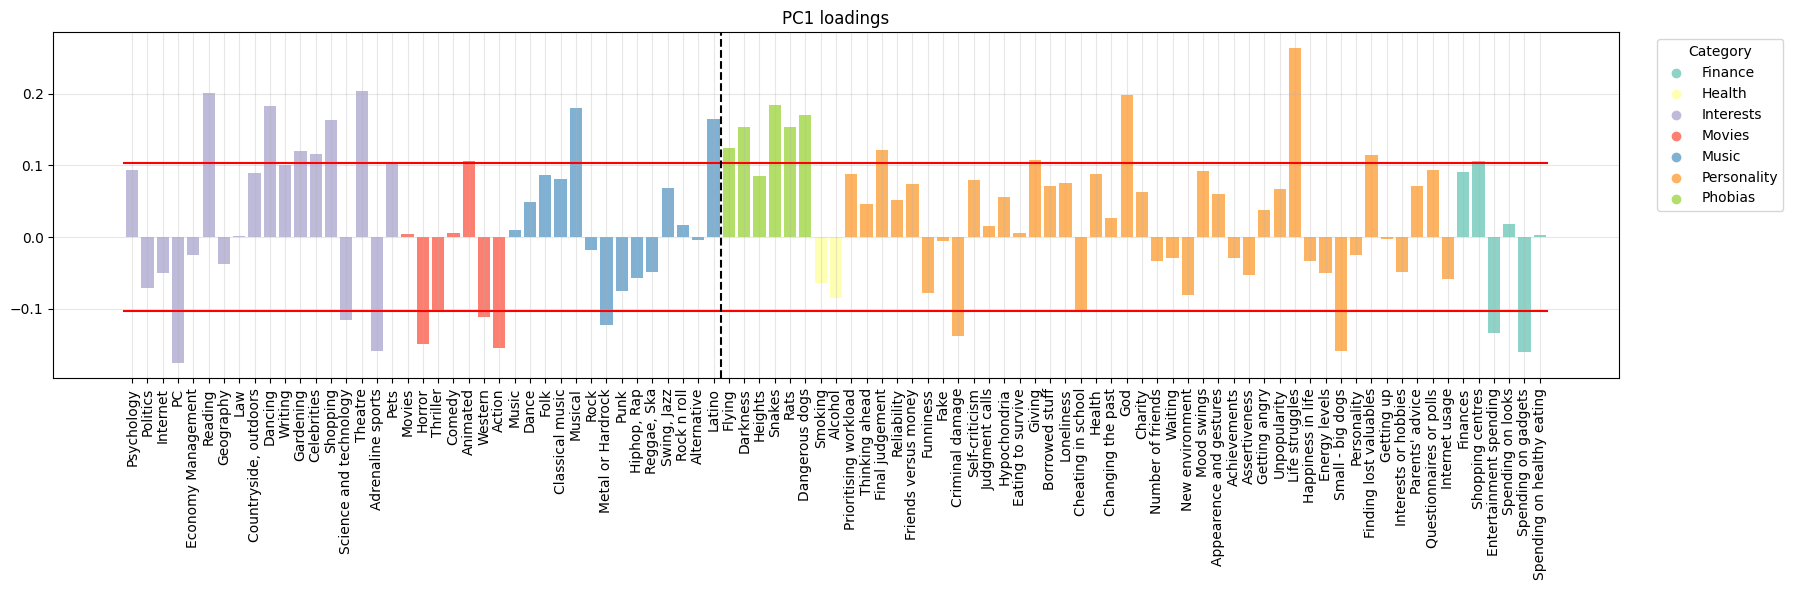


****************** PC1 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Reading', 'Dancing', 'Gardening', 'Celebrities', 'Shopping', 'Theatre', 'Animated', 'Musical', 'Latino', 'Flying', 'Darkness', 'Snakes', 'Rats', 'Dangerous dogs', 'Final judgement', 'Giving', 'God', 'Life struggles', 'Finding lost valuables', 'Shopping centres']

HIGH-VALUED NEGATIVE COMPONENTS: ['PC', 'Science and technology', 'Adrenaline sports', 'Horror', 'Western', 'Action', 'Metal or Hardrock', 'Criminal damage', 'Small - big dogs', 'Entertainment spending', 'Spending on gadgets']
*********************************************



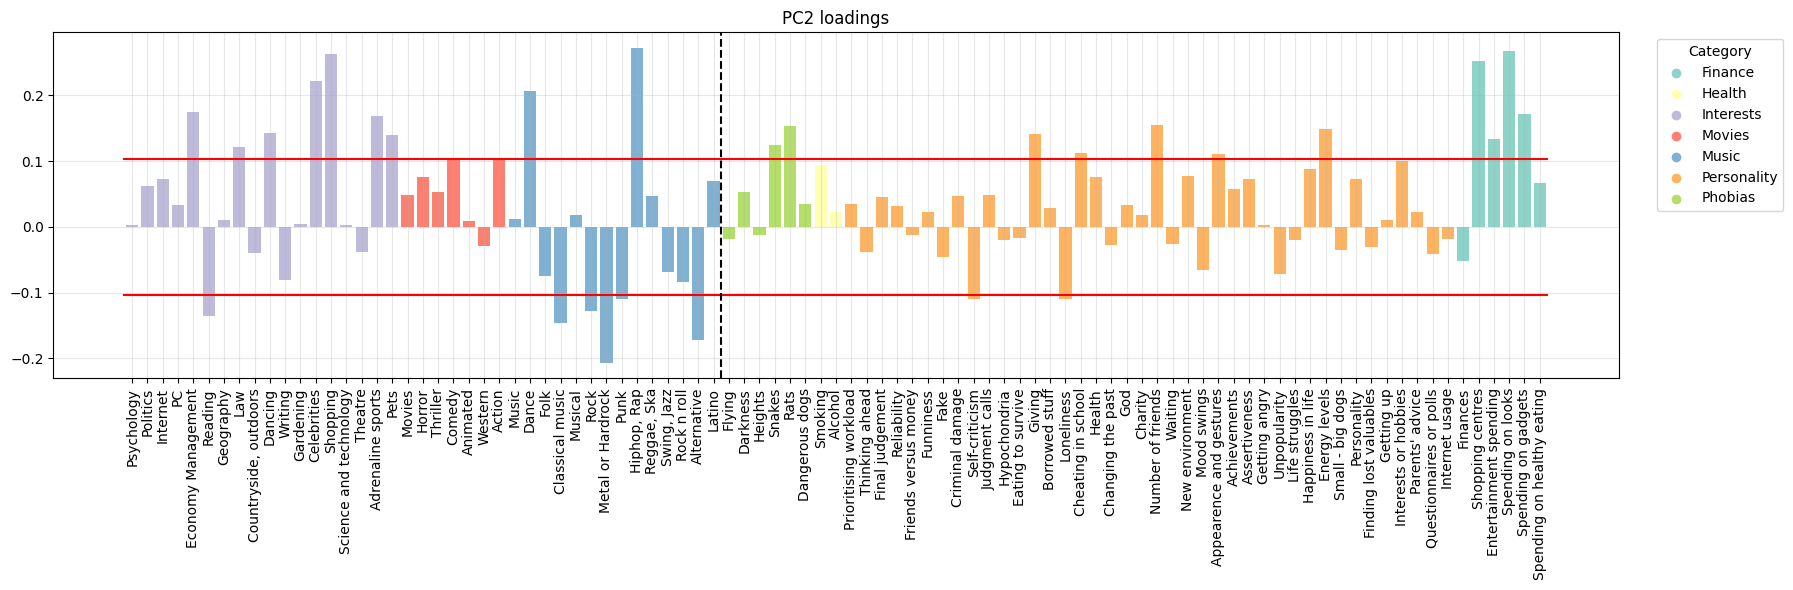


****************** PC2 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Economy Management', 'Law', 'Dancing', 'Celebrities', 'Shopping', 'Adrenaline sports', 'Pets', 'Dance', 'Hiphop, Rap', 'Snakes', 'Rats', 'Giving', 'Cheating in school', 'Number of friends', 'Appearence and gestures', 'Energy levels', 'Shopping centres', 'Entertainment spending', 'Spending on looks', 'Spending on gadgets']

HIGH-VALUED NEGATIVE COMPONENTS: ['Reading', 'Classical music', 'Rock', 'Metal or Hardrock', 'Punk', 'Alternative', 'Self-criticism', 'Loneliness']
*********************************************



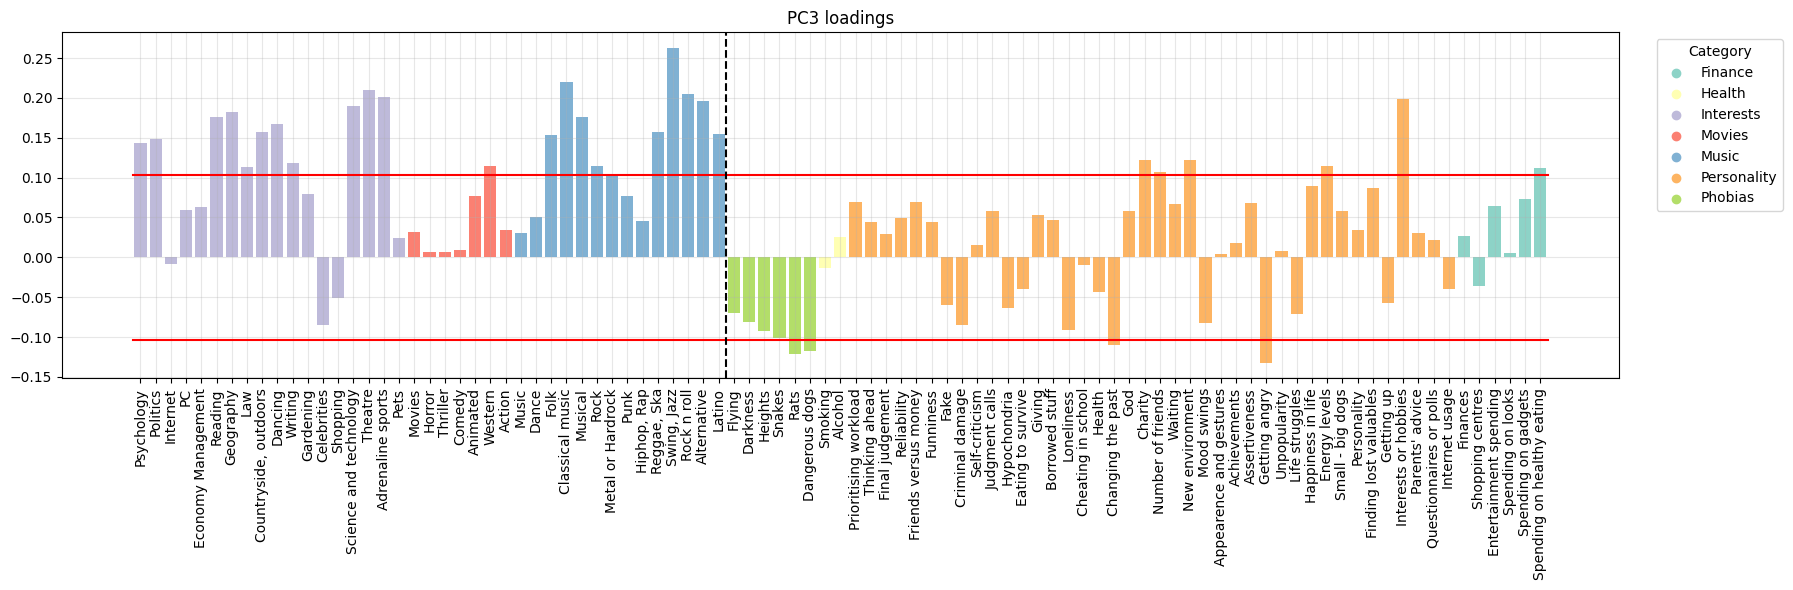


****************** PC3 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Psychology', 'Politics', 'Reading', 'Geography', 'Law', 'Countryside, outdoors', 'Dancing', 'Writing', 'Science and technology', 'Theatre', 'Adrenaline sports', 'Western', 'Folk', 'Classical music', 'Musical', 'Rock', 'Metal or Hardrock', 'Reggae, Ska', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 'Charity', 'Number of friends', 'New environment', 'Energy levels', 'Interests or hobbies', 'Spending on healthy eating']

HIGH-VALUED NEGATIVE COMPONENTS: ['Rats', 'Dangerous dogs', 'Changing the past', 'Getting angry']
*********************************************



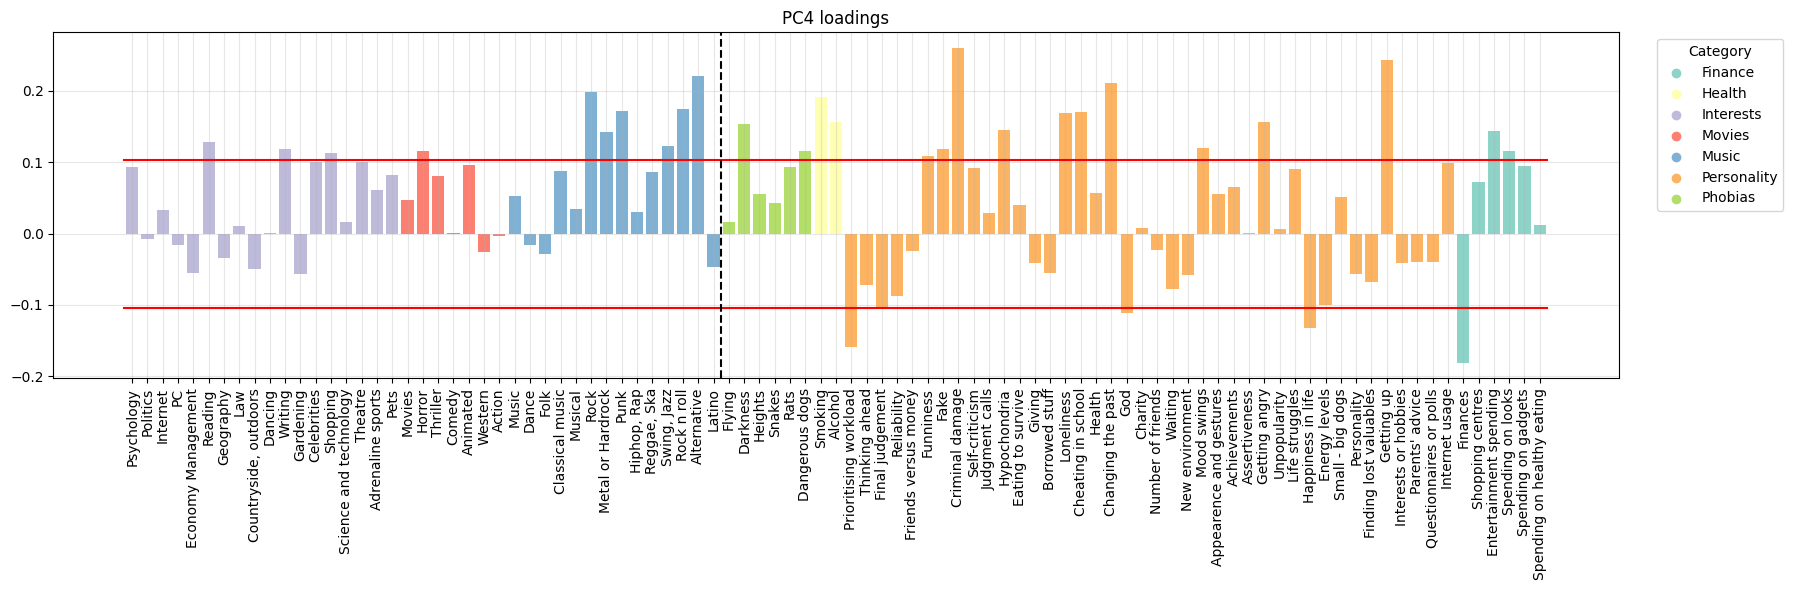


****************** PC4 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Reading', 'Writing', 'Shopping', 'Horror', 'Rock', 'Metal or Hardrock', 'Punk', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Darkness', 'Dangerous dogs', 'Smoking', 'Alcohol', 'Funniness', 'Fake', 'Criminal damage', 'Hypochondria', 'Loneliness', 'Cheating in school', 'Changing the past', 'Mood swings', 'Getting angry', 'Getting up', 'Entertainment spending', 'Spending on looks']

HIGH-VALUED NEGATIVE COMPONENTS: ['Prioritising workload', 'God', 'Happiness in life', 'Finances']
*********************************************



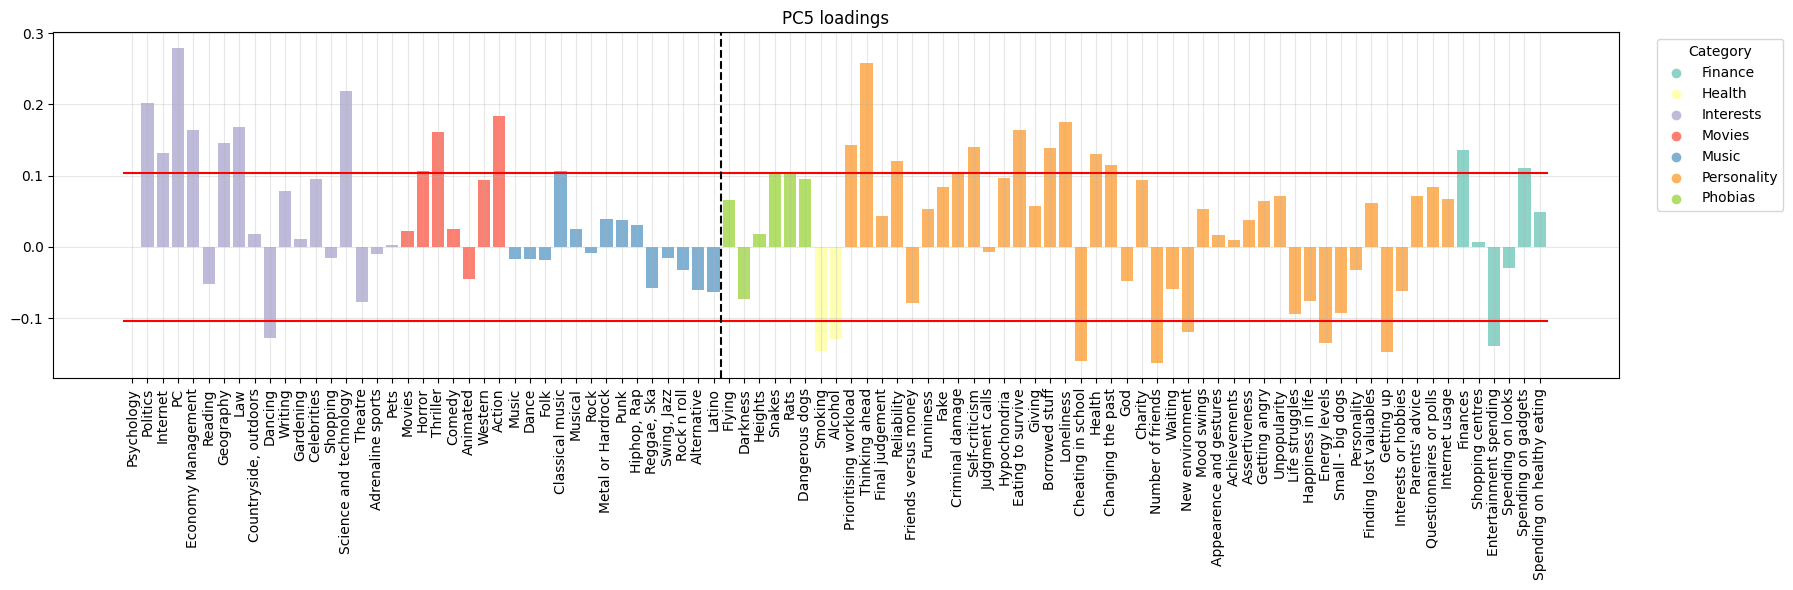


****************** PC5 **********************
HIGH-VALUED POSITIVE COMPONENTS: ['Politics', 'Internet', 'PC', 'Economy Management', 'Geography', 'Law', 'Science and technology', 'Horror', 'Thriller', 'Action', 'Classical music', 'Snakes', 'Rats', 'Prioritising workload', 'Thinking ahead', 'Reliability', 'Self-criticism', 'Eating to survive', 'Borrowed stuff', 'Loneliness', 'Health', 'Changing the past', 'Finances', 'Spending on gadgets']

HIGH-VALUED NEGATIVE COMPONENTS: ['Dancing', 'Smoking', 'Alcohol', 'Cheating in school', 'Number of friends', 'New environment', 'Energy levels', 'Getting up', 'Entertainment spending']
*********************************************



In [8]:
# m = 5 due to the fact that m' = 8
m=5
pca_responses_ft_pp_m = PCA(n_components=m)
pca_responses_ft_pp_m.fit(responses_ft_pp)

round_expl_var_ratio = np.round(pca_responses_ft_pp_m.explained_variance_ratio_.sum()*100, decimals=2)

# eps is a threshold to observe the most relevant features for each PC
eps = np.sqrt(1/pca_responses_ft_pp_m.n_features_in_)

X = responses_ft_pp

# PCs' explained variance
plt.figure(figsize=(6,6))
plt.bar(range(1,m+1),pca_responses_ft_pp_m.explained_variance_ratio_)
plt.title(f"PCs' EXPLAINED VARIANCE ({round_expl_var_ratio}% OF TOT.EXPL.VAR.)")
plt.xticks(np.arange(1,m+1),
           labels=[f'PC{i}' for i in range(1,m+1)],
           rotation=45)
plt.xlabel('Principal components')
plt.ylabel('Percentage of explained variance')
plt.grid(True, linestyle='--',linewidth=0.5,alpha=0.7)
plt.tight_layout()
plt.show()


# PCs barplots
colors = [column_color.get(col, 'gray') for col in X.columns]

for ii in range(m):
    plt.figure(figsize=(18, 6))
    plt.bar(np.arange(pca_responses_ft_pp_m.n_features_in_),
            pca_responses_ft_pp_m.components_[ii, :], color=colors)
    plt.plot([-0.5, pca_responses_ft_pp_m.n_features_in_ -0.5], [eps,eps], 'red')
    plt.plot([-0.5, pca_responses_ft_pp_m.n_features_in_ -0.5], [-eps,-eps], 'red')
    plt.axvline(x=vline_pos, color='black', linestyle='--', linewidth=1.5)
    for cat, color in category_colors.items():
            plt.scatter([], [], color=color, label=cat)
    plt.legend(title='Category', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.xticks(ticks=np.arange(pca_responses_ft_pp_m.n_features_in_),
               labels=X.columns.to_list(),
               rotation=90)
    plt.title(f"PC{ii+1} loadings")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    ind_great_pos_PCii = np.argwhere(pca_responses_ft_pp_m.components_[ii, :] >= eps).flatten()
    ind_great_neg_PCii = np.argwhere(pca_responses_ft_pp_m.components_[ii, :] <= -eps).flatten()

    great_pos_PCii = [X.columns[i] for i in ind_great_pos_PCii]
    great_neg_PCii = [X.columns[i] for i in ind_great_neg_PCii]

    print('')
    print(f'****************** PC{ii+1} **********************')
    print(f'HIGH-VALUED POSITIVE COMPONENTS: {great_pos_PCii}')
    print('')
    print(f'HIGH-VALUED NEGATIVE COMPONENTS: {great_neg_PCii}')
    print('*********************************************')
    print('')


#### For each PC, write the name you assigned to it and a brief interpretation that motivate the choice (max 100 words per PC):

##### PC1: (-) Tech-Action Orientation vs (+) Emotional-Spiritual
On the negative pole, there are technological interests, action-oriented preferences, financial focus, and low emotionality traits in personality. This pole is more strongly connected to technology and action.
On the positive pole, there are cultural and relaxing interests, musical preferences, 'Life struggles' in personality category, and phobias. This dimension is therefore more connected with humanity, spirituality and emotional sensitivity.

##### PC2: (-) Introverted Reflection vs (+) Social-Consumer Expressiveness
On the negative pole, there is a prevalence of music preferences, 'Reading' in personality category, and some introspective personality traits, which suggest an introverted profile.
On the positive pole, there are social and consumer-oriented interests such as 'Celebrities', 'Shopping', 'Hiphop, Rap' and 'Shopping centres', 'Spending on looks'. This direction captures consumer tendencies and social expressiveness.

##### PC3: (-) Emotional Reactivity vs (+) Entertainment
On the negative pole, there are phobias, 'Changing the past' and 'Getting angry' in personality category, all of which are related to emotional reactivity.
On the positive pole, there are almost all features connected with entertainment responses, indicating a strong orientation toward cultural and leisure activities.

##### PC4: (-) Stability vs (+) Transgression
On the negative pole, there are 'Finances' and indicators of life balance and well-being in the personality category. This pole can therefore be summarized as stability.
On the positive pole, there are music preferences, health behaviors, and several rebellious personality traits, which characterize a dimension of transgression.

##### PC5: (-) Social Vitality vs (+) Rationality
On the negative pole, there is a combination of relational personality traits, health behaviors and dancing interests, which can be grouped under social vitality.
On the positive pole, there are interests, movie preferences, and personality traits related to analytical thinking, self-control, and planning, which can be summarized as rationality.

#### Write the code for visualizing the score graph (with PC names on the axis):

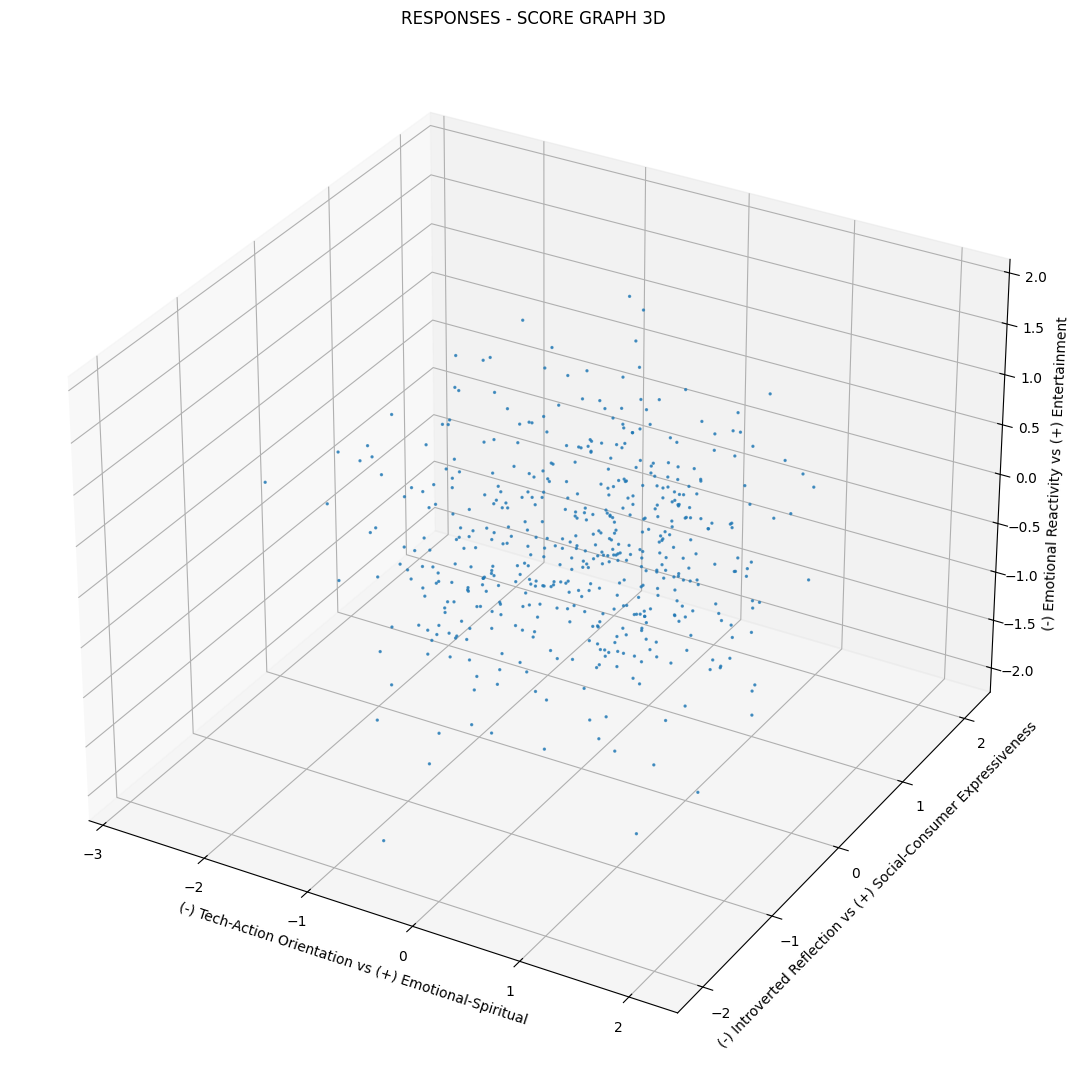

In [9]:
pc_names = ['(-) Tech-Action Orientation vs (+) Emotional-Spiritual',
            '(-) Introverted Reflection vs (+) Social-Consumer Expressiveness',
            '(-) Emotional Reactivity vs (+) Entertainment',
            '(-) Stability vs (+) Transgression',
            '(-) Social Vitality vs (+) Rationality']

# change of basis
Y = pca_responses_ft_pp_m.transform(X)
responses_ft_pca = pd.DataFrame(Y, columns=pc_names)

# 3D score graph
fig_res = plt.figure(figsize= (11,11))
ax = fig_res.add_subplot(111, projection='3d')
ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], s=2, alpha=0.7)
plt.title('RESPONSES - SCORE GRAPH 3D')
ax.set_xlabel(pc_names[0], fontsize=10)
ax.set_ylabel(pc_names[1], fontsize=10)
ax.set_zlabel(pc_names[2], fontsize=10)
plt.grid()
plt.tight_layout()
plt.show()

## Exercise 4. $k$-Means

In this exercise, you have to do the following operations:
1. Transform the *responses_ft_pp* data into their $m$-dimensional representation via PCA. Store the transformed data in the variable *responses_ft_pca*;
1. Run the $k$-Means for clustering the data of *responses_ft_pca*. In particular, **use the silohuette score for identifying the best value for $k\in\{3, \ldots, 10\}$** and show it by plotting how the score changes w.r.t. $k$.
1. Plot the score graph again, but add the centroids of the cluster and color the points according to their cluster.
1. Visualize the centroids coordinates as barplots and **give a name and an interpretation to them by exploiting the PC names**.


#### Write the code for performing the items of the list above:

Silhouette scores: [0.15941958881122792, 0.16567595792947243, 0.1541770712552679, 0.15952009869183723, 0.15446343791747716, 0.15287589037969804, 0.1561359015904033]
The best k is: 4


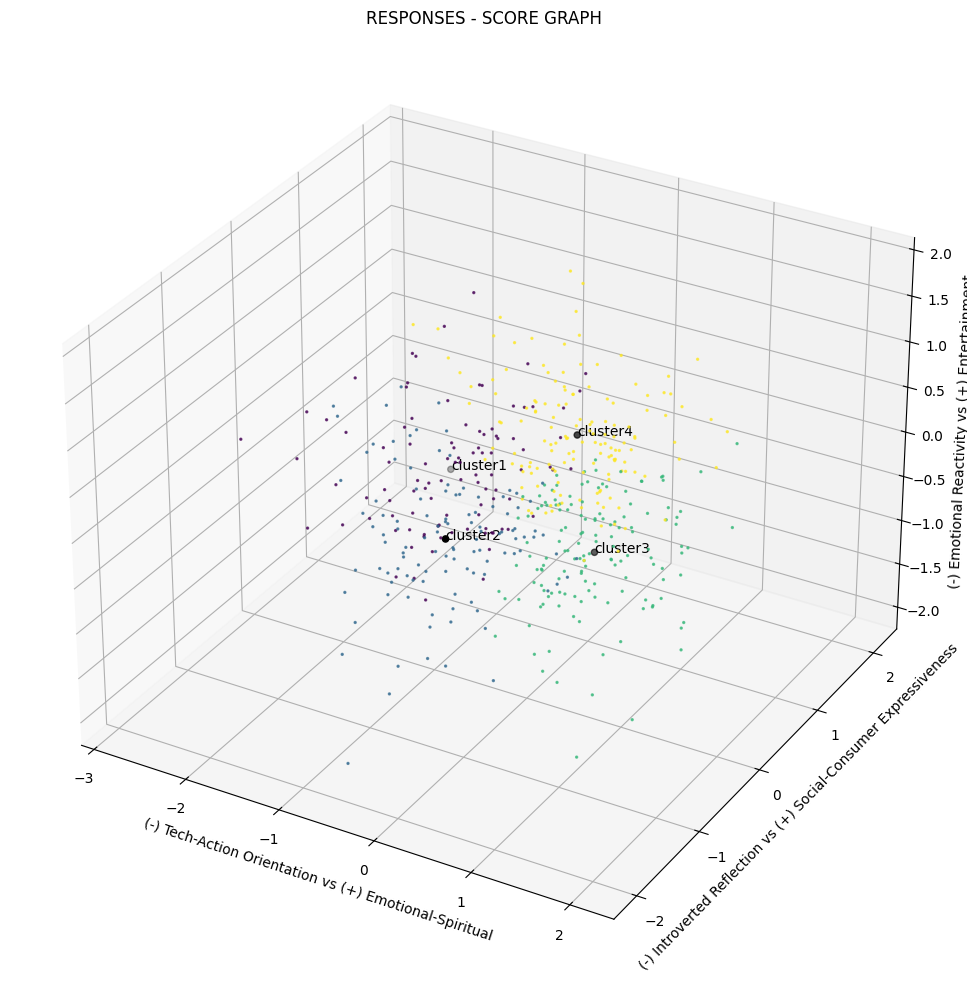

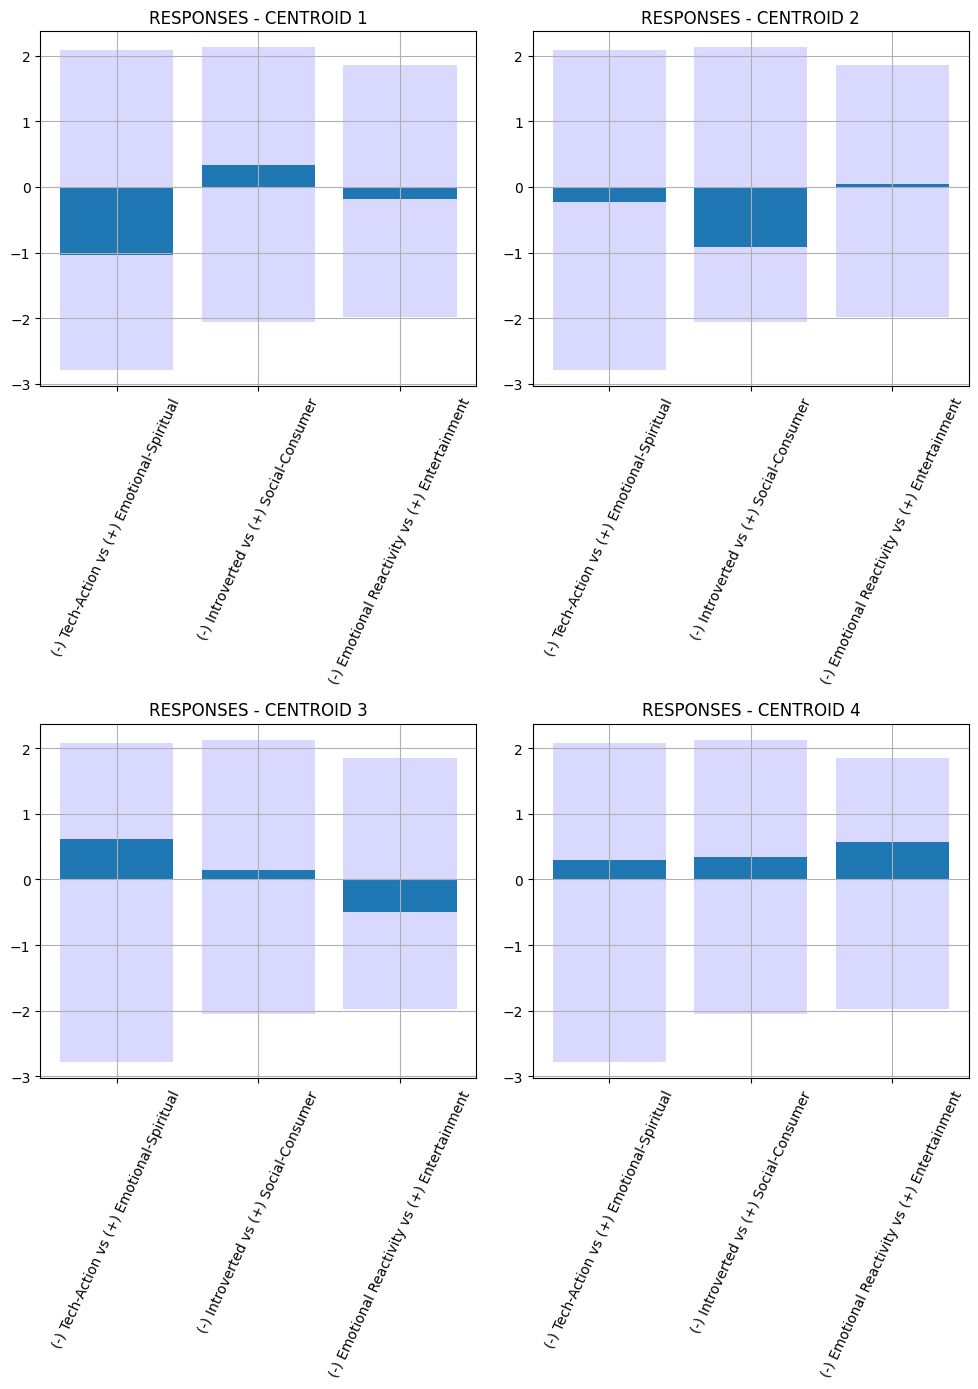

In [10]:
# for identifying the best value for k
K = range(3,10)
seed = 42
sil_score= []

for k in K:
    km_responses = KMeans(n_clusters=k, random_state=seed)
    km_responses.fit(responses_ft_pca)
    silcoeff = silhouette_score(responses_ft_pca, km_responses.labels_)
    sil_score.append(silcoeff)

print(f'Silhouette scores: {sil_score}\nThe best k is: {sil_score.index(max(sil_score))+3}')

k = sil_score.index(max(sil_score))+3
km_responses = KMeans(n_clusters=k, random_state=seed)
km_responses.fit(responses_ft_pca)
silcoeff = silhouette_score(responses_ft_pca, km_responses.labels_)

# score graph - 3D
sg_km = plt.figure(figsize= (10,10))
ax = sg_km.add_subplot(111, projection='3d')
ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], s=2, c=km_responses.labels_, alpha=0.7)
ax.scatter(km_responses.cluster_centers_[:,0],km_responses.cluster_centers_[:,1],km_responses.cluster_centers_[:,2], c='black', marker='o')
for kk in range(k):
    ax.text(km_responses.cluster_centers_[kk,0], km_responses.cluster_centers_[kk,1],km_responses.cluster_centers_[kk,2], f'cluster{kk+1}')
plt.title('RESPONSES - SCORE GRAPH')
ax.set_xlabel(pc_names[0])
ax.set_ylabel(pc_names[1])
ax.set_zlabel(pc_names[2])
plt.grid()
plt.tight_layout()
plt.show()

maxs_res_m = responses_ft_pca.max(axis=0)
mins_res_m = responses_ft_pca.min(axis=0)

# reduced pc names
pc_names_red = ['(-) Tech-Action vs (+) Emotional-Spiritual',
            '(-) Introverted vs (+) Social-Consumer',
            '(-) Emotional Reactivity vs (+) Entertainment',
            '(-) Stability vs (+) Transgression',
            '(-) Social Vitality vs (+) Rationality']

# centroids coordinates as barplots
fig_centroids, ax_centroids = plt.subplots(2, 2, figsize=(10, 14))
for ii in range(k):
    ir= ii//2
    ic= ii%2
    n_pc = 3
    ax_centroids[ir,ic].bar(np.arange(n_pc), maxs_res_m[:n_pc], color='blue', alpha=0.15)
    ax_centroids[ir,ic].bar(np.arange(n_pc), mins_res_m[:n_pc], color='blue', alpha=0.15)
    ax_centroids[ir,ic].bar(np.arange(n_pc), km_responses.cluster_centers_[ii, :n_pc])
    ax_centroids[ir,ic].set_xticks(ticks=np.arange(n_pc))
    ax_centroids[ir,ic].set_xticklabels(labels=pc_names_red[:n_pc], rotation=65)
    ax_centroids[ir,ic].grid(visible=True, which='both')
    ax_centroids[ir,ic].set_title(f'RESPONSES - CENTROID {ii+1}')
plt.tight_layout()
plt.show()


#### For each Centroid, write the name you assigned to it and a brief interpretation that motivate the choice by exploiting the PC names(max 100 words per centroid):

##### Centroid 1: Tech-Action Orientation
This centroid is mainly associated with the negative pole of PC1, which represents a tech-action orientation. Individuals in this cluster show a stronger focus on technology, action-oriented activities, and pragmatic interests, combined with lower emotional and spiritual sensitivity. This profile reflects a preference for instrumental, performance-driven behaviors rather than cultural or emotionally expressive ones.

##### Centroid 2: Introverted Reflection
This centroid is primarily defined by the negative pole of PC2, corresponding to introverted reflection. It captures individuals characterized by introspective traits, solitary cultural interests such as reading and non-popular music, and higher self-reflection. Social and consumer-oriented behaviors are less prominent in this cluster.

##### Centroid 3: Emotional Sensitivity and Reactivity
This centroid is characterized by the positive pole of PC1 (Emotional–Spiritual) and the negative pole of PC3 (Emotional Reactivity). It represents individuals with high emotional sensitivity, spiritual, and greater vulnerability to emotional responses. This cluster reflects a strong emotional engagement with personal experiences.

##### Centroid 4: Social and Cultural Entertainment
This centroid is mainly associated with the positive pole of PC3, which captures entertainment and cultural aspects. Individuals in this cluster show a strong orientation toward leisure activities, cultural consumption, music, movies, and diverse interests.
There is also a contribution from the positive pole of PC1 and PC2, which are related to an emotional sensitivity and social-consumer tendencies.


## Exercise 5. Cluster External Evaluations

In this exercise, you have to do the following operations:
1. Select a subset meaningful labels for performing an external evaluation of the clustering results.
1. For each selected label, visualize the distribution of the label in each cluster and in the whole dataset. Moreover, visualize the clusters in separated score-graphs, coloring the points according to the label values.


#### List the Labels you consider meaningful for an external cluster evaluation and motivate your choice (max 50 words per label):

The labels that appear meaningful for external cluster evaluation are 'Gender' and 'Weight', as their distributions vary across clusters. Other labels show similar proportions in all clusters and therefore do not provide informative differences for assessing cluster quality.


#### Write the code for the visualizations cited in item 2 above:

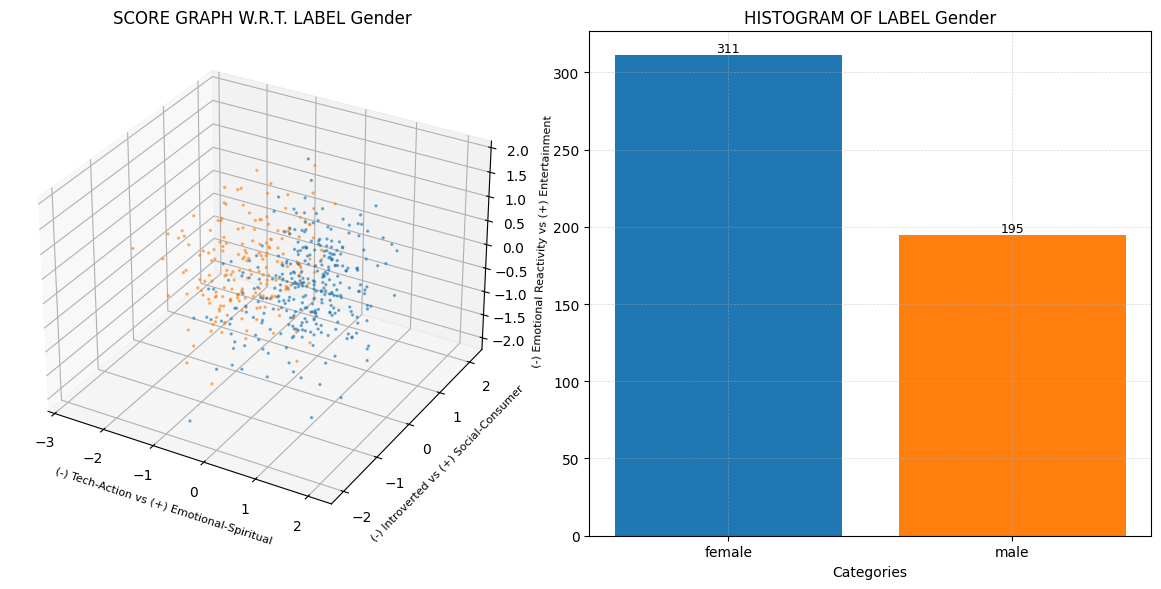

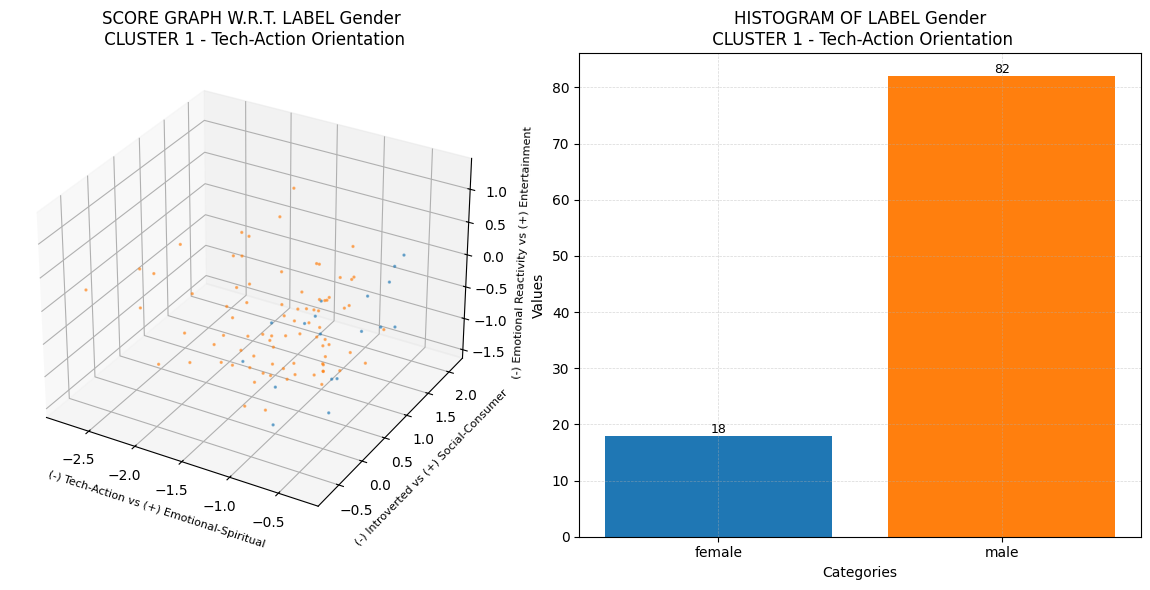

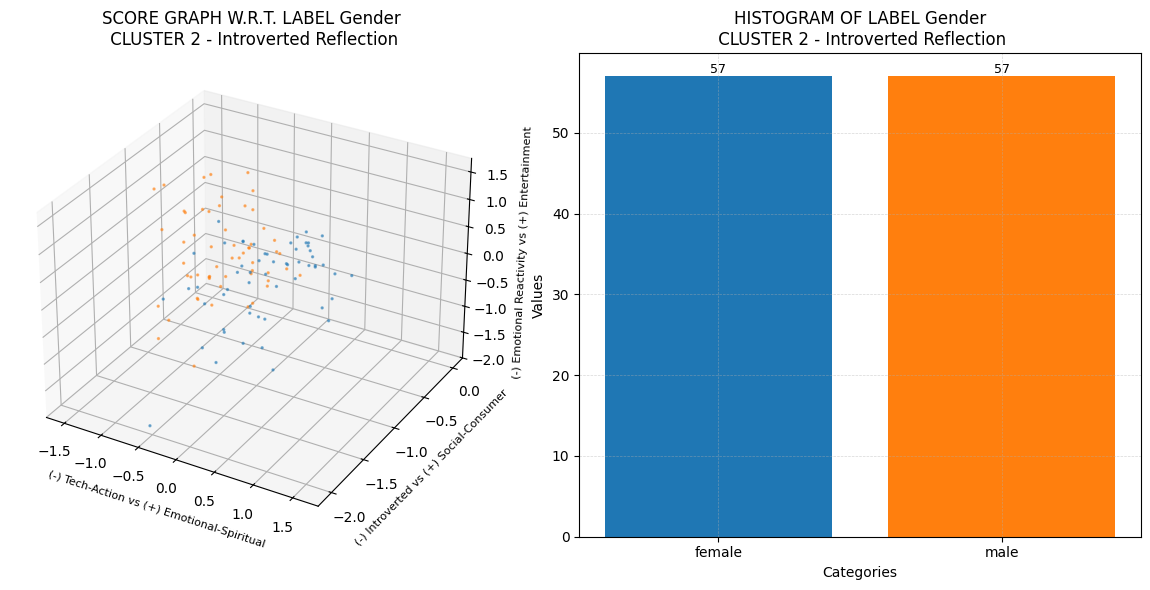

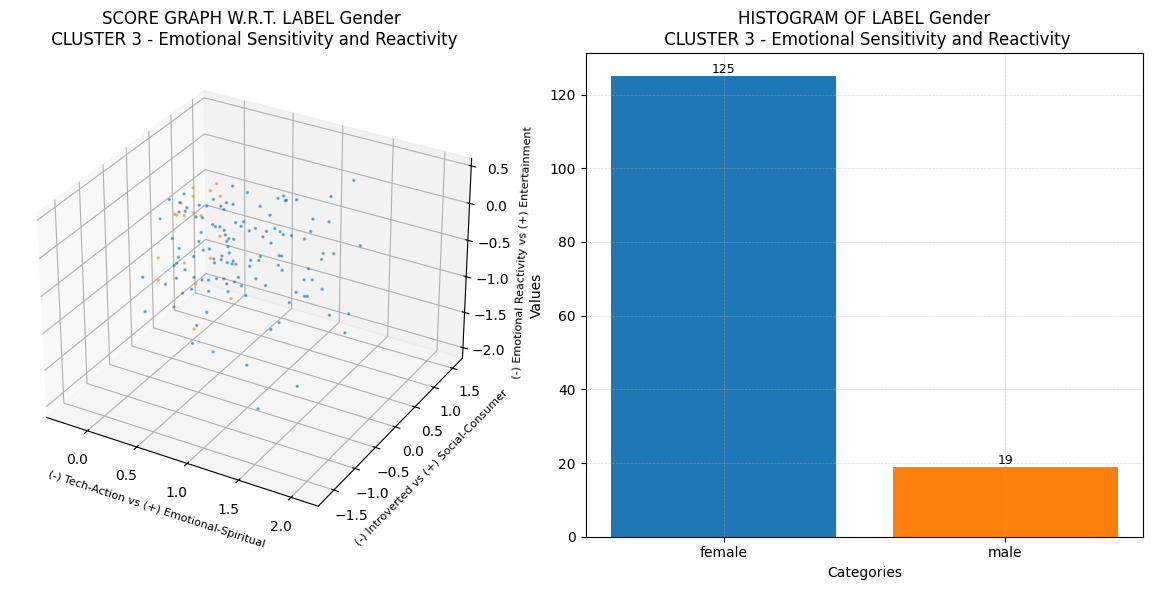

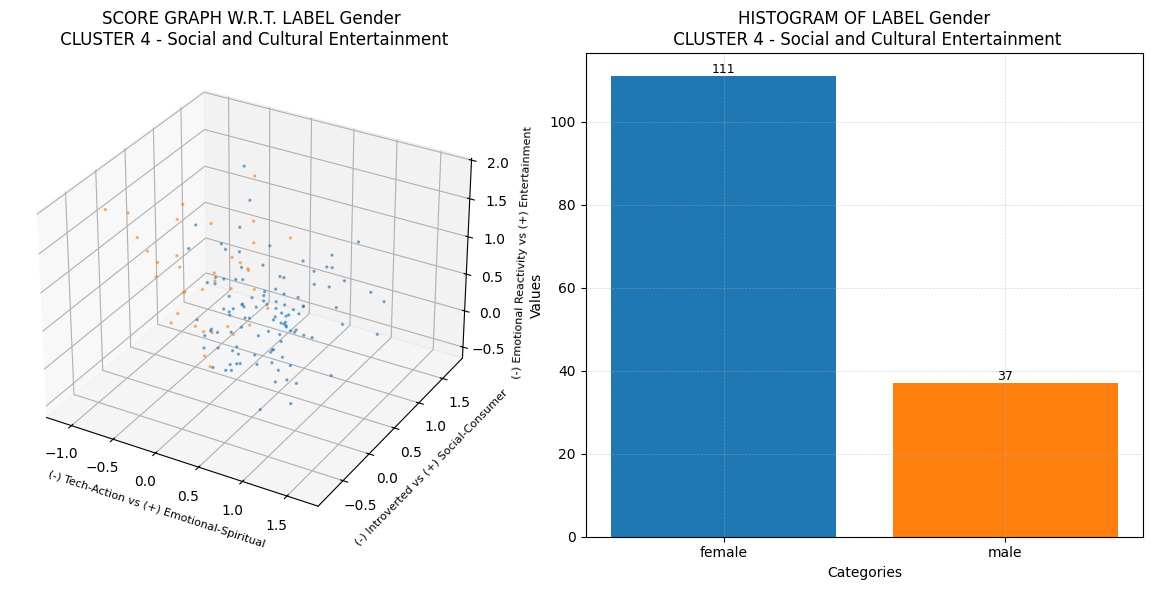

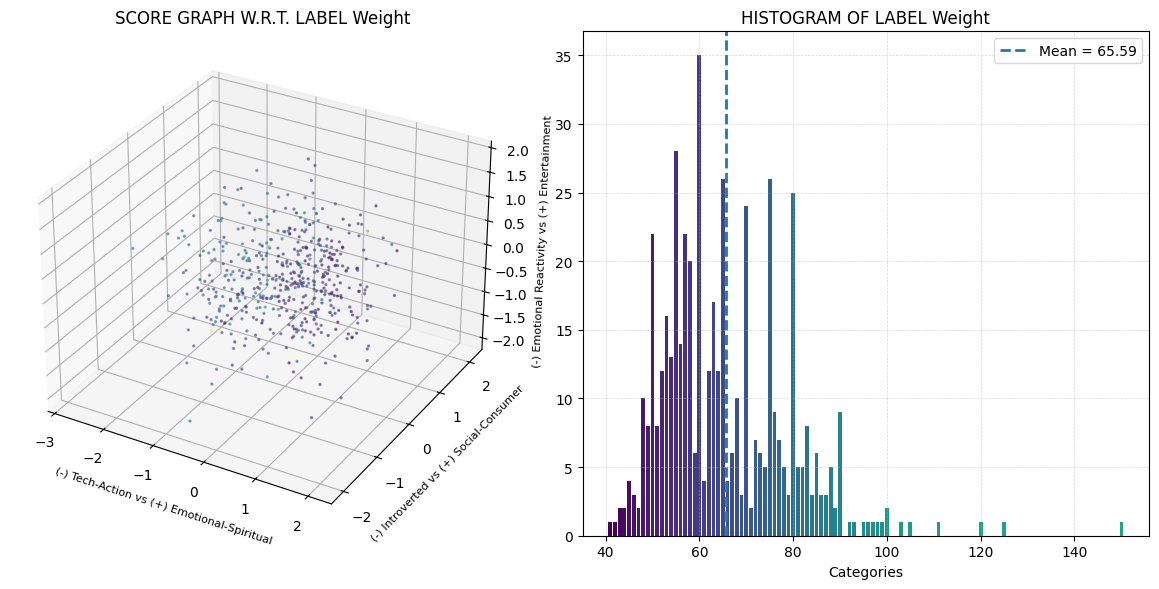

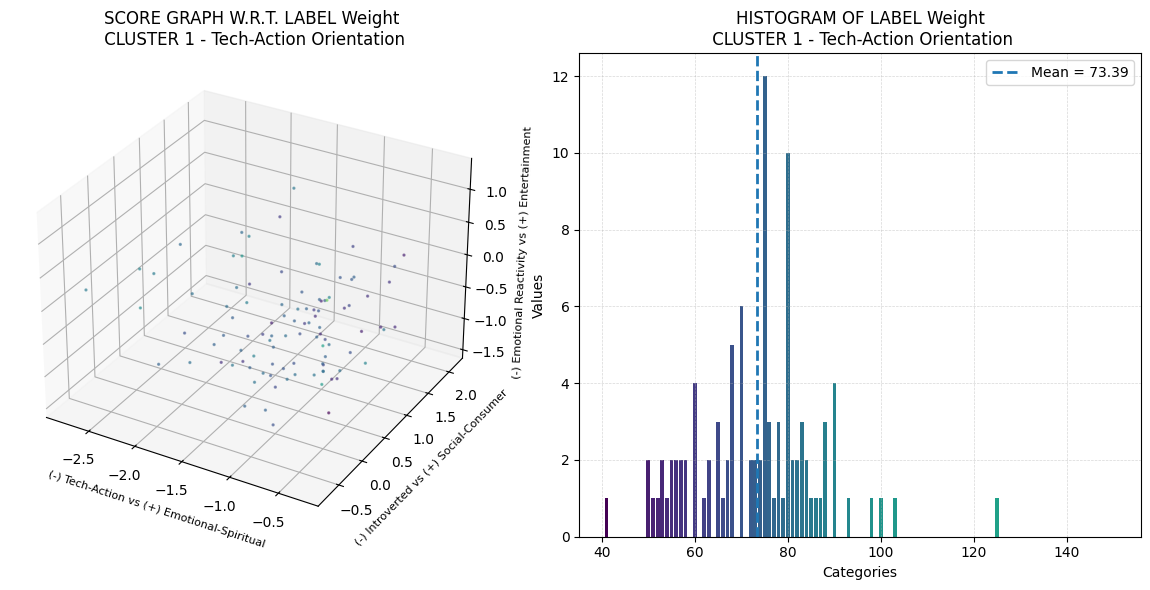

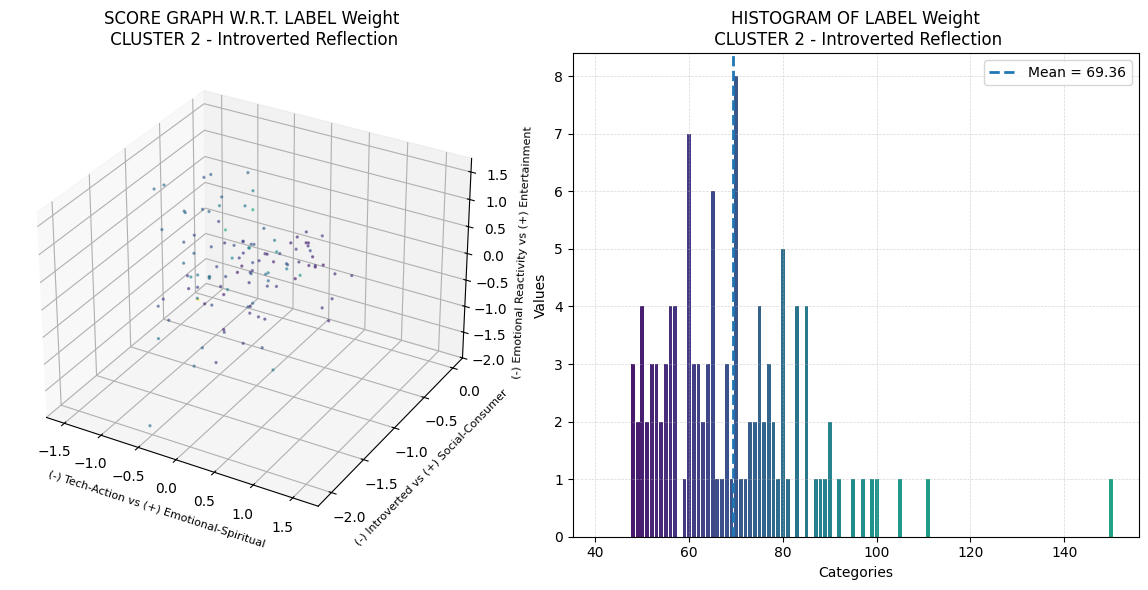

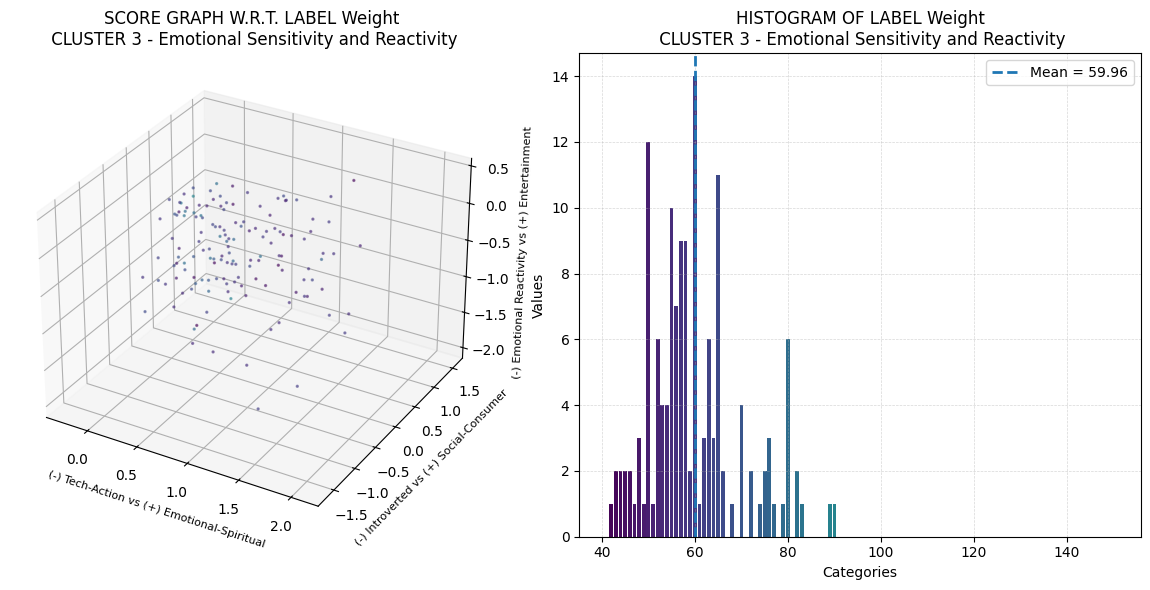

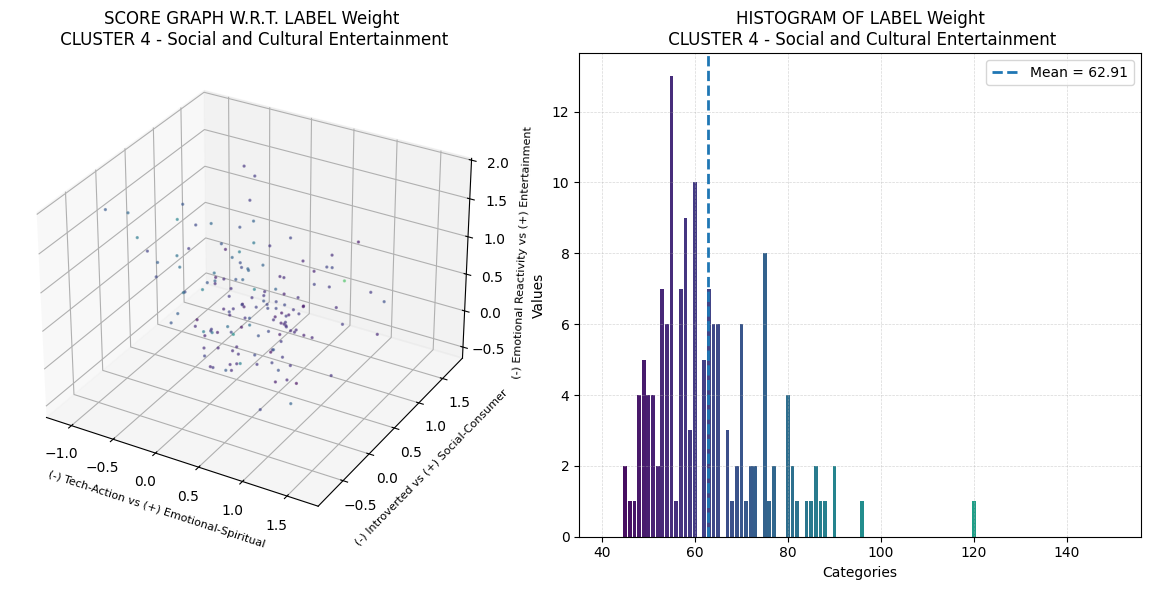

In [11]:
centroids_names= ['Tech-Action Orientation','Introverted Reflection','Emotional Sensitivity and Reactivity','Social and Cultural Entertainment']
selected_labels = ['Gender','Weight']

for lb in selected_labels:
    lb_values, lb_counts = np.unique(responses_lb[lb].values, return_counts=True)
    if lb == 'Weight':
        n_colors_hist = responses_lb[lb].max() - responses_lb[lb].min() +1
        cmap_hist = plt.get_cmap('viridis')
        color_hist = cmap_hist(np.linspace(0, 1, n_colors_hist))
        color_scat = [color_hist[ll- responses_lb[lb].min(), :3] for ll in responses_lb[lb].values]
    else:
        n_colors_hist = lb_values.size
        cmap_hist = plt.get_cmap('tab10')
        color_scat_dict = {lb_values[ii]: ii for ii in range(len(lb_values))}
        color_scat = [cmap_hist(color_scat_dict[ll]) for ll in responses_lb[lb].values]
        color_hist = cmap_hist(np.arange(0, n_colors_hist))

    color_hist = color_hist[:,:3]

    # global plots
    fig_lb = plt.figure(figsize= (12,6))

    ax1 = fig_lb.add_subplot(1,2,1, projection='3d')
    scat1 = ax1.scatter(Y[:, 0], Y[:, 1], Y[:, 2], s=2, c=color_scat, alpha=0.5)
    ax1.set_title(f'SCORE GRAPH W.R.T. LABEL {lb}')
    ax1.set_xlabel(pc_names_red[0], fontsize=8)
    ax1.set_ylabel(pc_names_red[1], fontsize=8)
    ax1.set_zlabel(pc_names_red[2], fontsize=8)
    ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    plt.tight_layout()

    ax2 = fig_lb.add_subplot(1,2,2)
    ax2.bar(lb_values, lb_counts, color = color_hist)
    if lb == 'Weight' or lb == 'Age':
        mean_value = np.average(lb_values, weights=lb_counts)
        ax2.axvline(x=mean_value, linestyle='--', linewidth=2, label=f'Mean = {mean_value:.2f}')
        ax2.legend()
    else:
        for x, count in zip(lb_values, lb_counts):
            ax2.text(x,count,str(count),ha='center',va='bottom',fontsize=9)
    ax2.set_title(f'HISTOGRAM OF LABEL {lb}')
    ax2.set_xlabel('Categories')
    ax.set_ylabel('Values')
    ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    plt.tight_layout()

    plt.show()

    # cluster plots
    for cc in range(km_responses.cluster_centers_.shape[0]):
        where_cc = np.argwhere(km_responses.labels_ == cc).flatten()
        cc_values_, cc_counts_ = np.unique(responses_lb[lb].values[where_cc], return_counts=True)
        new_counts = np.zeros_like(lb_values, dtype=int)

        for val, count in zip(cc_values_, cc_counts_):
            idx = np.where(lb_values == val)[0]
            new_counts[idx] = count

        cc_values_ = lb_values
        cc_counts_ = new_counts

        fig_cc = plt.figure(figsize= (12,6))

        ax1 = fig_cc.add_subplot(1,2,1, projection='3d')
        scat1 = ax1.scatter(Y[where_cc, 0], Y[where_cc, 1], Y[where_cc, 2], s=2, c=[color_scat[wcc] for wcc in where_cc], alpha=0.5)
        ax1.set_title(f'SCORE GRAPH W.R.T. LABEL {lb}\n CLUSTER {cc+1} - {centroids_names[cc]}')
        ax1.set_xlabel(pc_names_red[0], fontsize=8)
        ax1.set_ylabel(pc_names_red[1], fontsize=8)
        ax1.set_zlabel(pc_names_red[2], fontsize=8)
        ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
        plt.tight_layout()

        ax2 = fig_cc.add_subplot(1,2,2)
        ax2.bar(lb_values, cc_counts_, color = color_hist)
        if lb == 'Weight' or lb == 'Age':
            mean_cc = np.average(lb_values, weights=cc_counts_)
            ax2.axvline(x=mean_cc, linestyle='--', linewidth=2, label=f'Mean = {mean_cc:.2f}')
            ax2.legend()
        else:
            vals, counts = np.unique(responses_lb[lb].values, return_counts=True)
            global_perc = counts / counts.sum()
            for x, count in zip(lb_values, cc_counts_):
                ax2.text(x,count,str(count),ha='center',va='bottom',fontsize=9)
        ax2.set_title(f'HISTOGRAM OF LABEL {lb}\n CLUSTER {cc+1} - {centroids_names[cc]}')
        ax2.set_xlabel('Categories')
        ax2.set_ylabel('Values')
        ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
        plt.tight_layout()

        plt.show()


#### For each selected label, comment the results observed in the visualizations (max 100 words per label):

##### Gender:
In general, practical characteristics tend to be associated more with males, while emotional traits are more associated with females. This pattern is also observable in these clusters: the ‘Tech-Action Orientation’ cluster has a higher percentage of males, whereas the ‘Emotional Sensitivity and Reactivity’ cluster has a higher percentage of females compared to the global distribution. The ‘Introverted Reflection’ cluster has equal number of males and females, but men are overrepresented relative to the overall population. Finally, the ‘Social and Cultural Entertainment’ cluster is largely neutral regarding gender.


##### Weight:
Considering the analysis by gender, there appears to be a correlation between weight and gender. Clusters with a higher proportion of males tend to have an average weight above the global mean, while clusters with a predominance of females tend to have an average weight below the global mean. This pattern reflects the overall differences in weight between genders, and it is observable in the cluster distributions, showing that the gender composition within each cluster influences the average weight values relative to the total population.

## Exercise 6. Cluster Internal Evaluations

In this exercise, you have to do the following operations:
1. For each cluster, measure the corresponding average silhouette score
1. Visualize the silhouette of the clusters and the general one of the clustering and compare them


#### Write the code for computing the silhouette scores and for visualizing them:

,Sil. Score
Tech-Action,0.179068
Introverted,0.161431
Emotional,0.177793
Entertainment,0.148107
Global,0.165676


<function matplotlib.pyplot.show(close=None, block=None)>

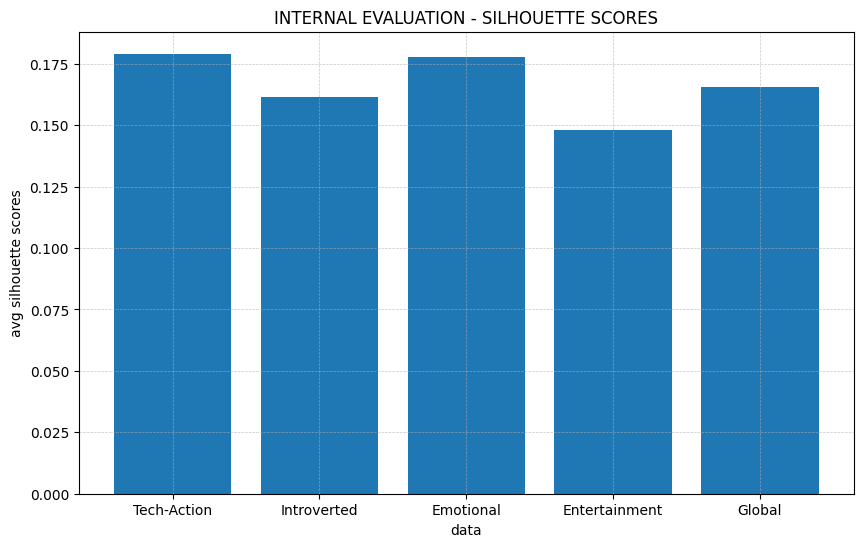

In [12]:
silscores = silhouette_samples(Y, km_responses.labels_)
cluster_silscores = [np.mean(silscores[km_responses.labels_ == kk]) for kk in range(k)]

centroids_names_red= ['Tech-Action','Introverted','Emotional','Entertainment']

# avg silhouette scores
silcoeffs_df = pd.DataFrame(np.array(cluster_silscores + [silcoeff]), index = centroids_names_red + ['Global'],  columns = ['Sil. Score'] )

display(silcoeffs_df)

# visualization for avg silhouette scores
plt.figure(figsize=(10,6))
plt.bar(silcoeffs_df.index.tolist(), silcoeffs_df['Sil. Score'].values)
plt.xlabel('data')
plt.ylabel('avg silhouette scores')
plt.title('INTERNAL EVALUATION - SILHOUETTE SCORES')
plt.grid(True, linestyle='--',linewidth=0.5,alpha=0.7)
plt.show

#### Comment the results, also considering the results observed previously (e.g., score graphs, centroids, etc. - max 150 words):

Silhouette scores range from -1 to 1, where higher values indicate better separation and cohesion within clusters. The average scores for these clusters are all positive but relatively low, ranging from 0.148 to 0.179, suggesting that the clusters exist but are not sharply separated. The ‘Tech-Action’ and ‘Emotional’ clusters have the highest average scores, indicating stronger internal cohesion. These clusters also show a clearer distinction in gender composition, with ‘Tech-Action’ having more males and ‘Emotional’ more females relative to the global distribution. In contrast, the ‘Entertainment’ cluster has the lowest score and appears more heterogeneous. The global silhouette score (0.166) confirms moderate clustering quality. This is also reflected in the score graph, where the data points form a diffuse cloud, and cluster boundaries are not easily distinguishable.